# Where the World Is Going: Demography, Prosperity and Economic Resilience

This Elite notebook preserves the complete visual record from the seven-part global development series. The accompanying article uses three selected figures; every available original output remains here for readers who want to inspect the wider analysis.


## Source ? Demographic change

---


# Global Demographic Trends: Where the World is Going

**Objective**: Analyze UN demographic indicators (1950-2023) to understand global population dynamics and development patterns. We'll examine: (1) global aging and longevity trends, (2) regional demographic divergence, and (3) the relationship between population aging and life expectancy as indicators of socioeconomic development.

In [1]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_excel('../data/UN_demographic_indicators.xlsx', sheet_name='Estimates', skiprows=16)

In [2]:
# convert columns to numeric after 'Year'
numeric_columns = data.columns[11:]
data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# remove unecessary columns, index
data = data.drop(columns=['Index'])

# rename some common columns
data = data.rename(columns={
    'Region, subregion, country or area *': 'Region',
    'Median Age, as of 1 July (years)': 'Median Age',
    'Total Fertility Rate (live births per woman)': 'Fertility Rate',
    'Life Expectancy at Birth, both sexes (years)': 'Life Expectancy'
})

## UN Demographic Data Processing

**Technical Approach**: UN Population Division data requires careful column handling and renaming for analysis clarity. Converting numeric columns ensures proper statistical operations while removing index columns streamlines the dataset. The demographic indicators span 73 years (1950-2023), providing comprehensive historical perspective on global population changes.

In [3]:
# view data
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21983 entries, 0 to 21982
Data columns (total 64 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Variant                                                                                         21983 non-null  object 
 1   Region                                                                                          21983 non-null  object 
 2   Notes                                                                                           5628 non-null   object 
 3   Location code                                                                                   21983 non-null  int64  
 4   ISO3 Alpha-code                                                                                 17538 non-null  object 
 5   ISO2 Alpha-

,Variant,Region,Notes,Location code,ISO3 Alpha-code,ISO2 Alpha-code,SDMX code**,Type,Parent code,Year,...,"Male Mortality before Age 60 (deaths under age 60 per 1,000 male live births)","Female Mortality before Age 60 (deaths under age 60 per 1,000 female live births)","Mortality between Age 15 and 50, both sexes (deaths under age 50 per 1,000 alive at age 15)","Male Mortality between Age 15 and 50 (deaths under age 50 per 1,000 males alive at age 15)","Female Mortality between Age 15 and 50 (deaths under age 50 per 1,000 females alive at age 15)","Mortality between Age 15 and 60, both sexes (deaths under age 60 per 1,000 alive at age 15)","Male Mortality between Age 15 and 60 (deaths under age 60 per 1,000 males alive at age 15)","Female Mortality between Age 15 and 60 (deaths under age 60 per 1,000 females alive at age 15)",Net Number of Migrants (thousands),"Net Migration Rate (per 1,000 population)"
0,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1950.0,...,580.500,497.388,238.516,268.734,207.620,375.391,426.221,322.650,0.0,0.0
1,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1951.0,...,566.566,488.435,229.703,256.236,202.734,365.226,412.760,316.395,0.0,0.0
2,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1952.0,...,546.444,475.370,217.311,238.560,195.926,350.613,393.364,307.314,0.0,0.0
3,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1953.0,...,535.811,467.361,211.257,230.961,191.482,342.734,383.875,301.270,0.0,0.0
4,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1954.0,...,522.058,455.621,203.337,221.377,185.296,332.327,371.737,292.807,0.0,0.0


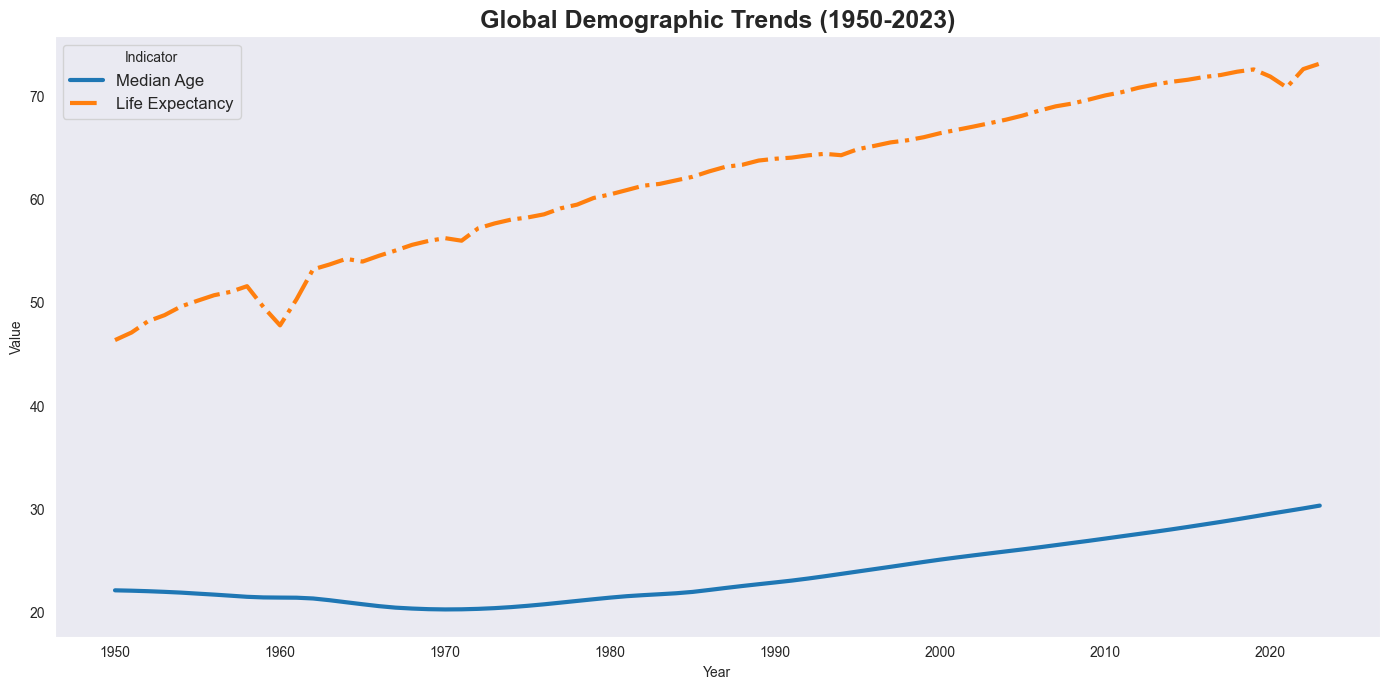

In [4]:
# refresh the data 
df = data.copy()

# use only world data
world_df = df[df['Region'] == 'World']

# build the plot
sns.set_style("dark")
plt.figure(figsize=(14, 7))
sns.lineplot(data=world_df, x='Year', y='Median Age', label='Median Age', linewidth=3, linestyle='-')
sns.lineplot(data=world_df, x='Year', y='Life Expectancy', label='Life Expectancy', linewidth=3, linestyle='-.')

# Add titles and labels
plt.title('Global Demographic Trends (1950-2023)', fontsize=18, weight='bold')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(title='Indicator', fontsize=12)
plt.tight_layout()
plt.show()


## Global Demographic Transformation

**Key Insight**: World data reveals two fundamental trends - population aging (rising median age) and increasing longevity (life expectancy). These parallel trends represent the demographic transition as societies move from high birth/death rates to low birth/death rates, fundamentally reshaping global age structures and dependency ratios.

In [5]:
df['Region'].unique()

array(['World', 'Sustainable Development Goal (SDG) regions',
       'Sub-Saharan Africa', 'Northern Africa and Western Asia',
       'Central and Southern Asia', 'Eastern and South-Eastern Asia',
       'Latin America and the Caribbean',
       'Oceania (excluding Australia and New Zealand)',
       'Australia/New Zealand', 'Europe and Northern America',
       'Europe, Northern America, Australia, and New Zealand',
       'UN development groups', 'More developed regions',
       'Less developed regions', 'Least developed countries',
       'Less developed regions, excluding least developed countries',
       'Less developed regions, excluding China',
       'Land-locked Developing Countries (LLDC)', 'LLDC: Africa',
       'LLDC: Asia', 'LLDC: Europe', 'LLDC: Latin America',
       'Small Island Developing States (SIDS)', 'SIDS Caribbean',
       'SIDS Pacific',
       'SIDS Atlantic, Indian Ocean and South China Sea (AIS)',
       'World Bank income groups',
       'High-and-upper-mi

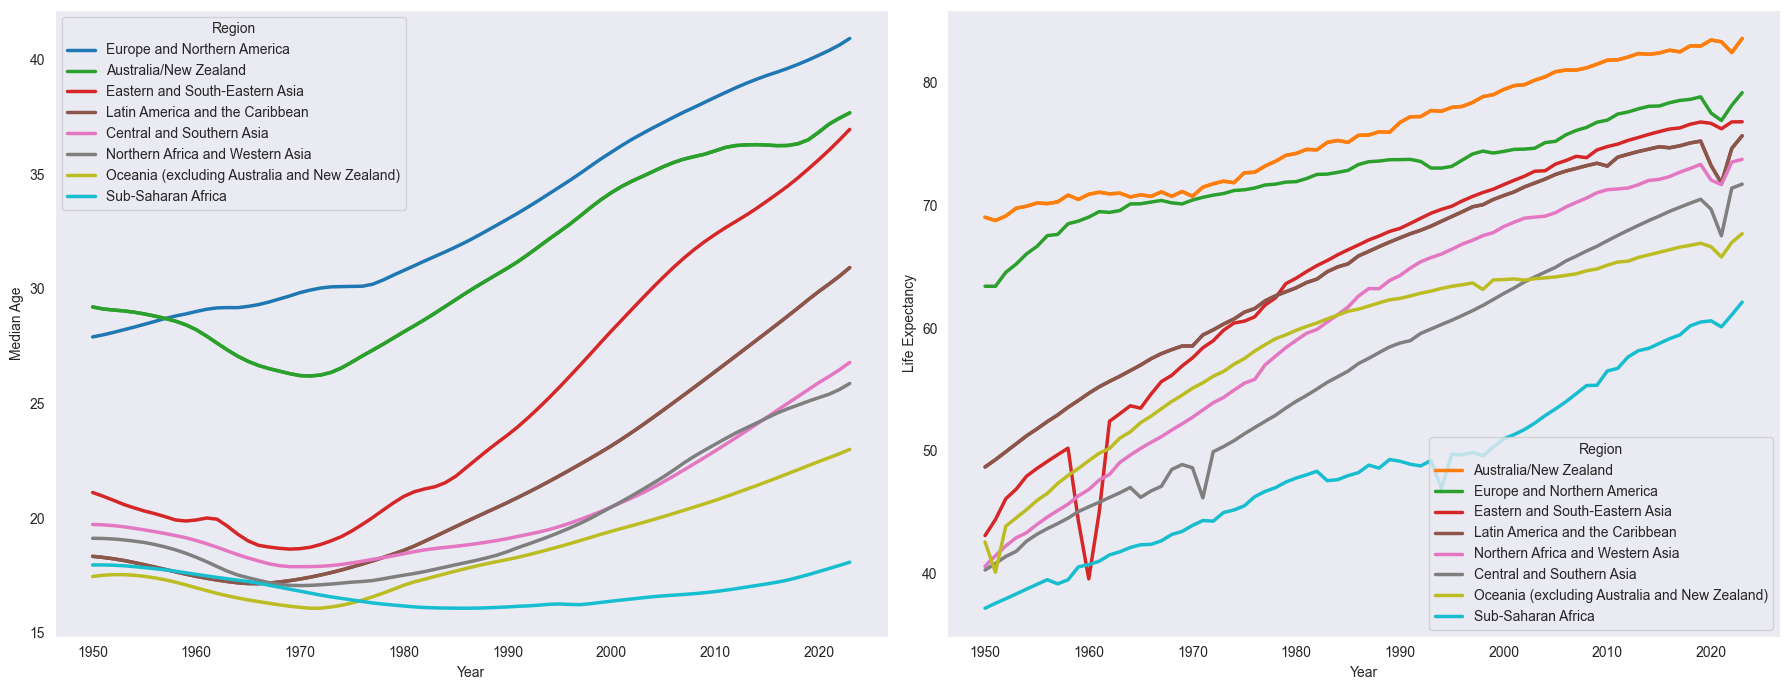

In [6]:
# select world by region
selected_regions = [
    'Sub-Saharan Africa',
    'Central and Southern Asia',
    'Eastern and South-Eastern Asia',
    'Northern Africa and Western Asia',
    'Oceania (excluding Australia and New Zealand)',
    'Australia/New Zealand',
    'Europe and Northern America',
    'Latin America and the Caribbean',
]

# group into a df
region_df = df[df['Region'].isin(selected_regions)].copy()

# Get the latest year in your dataset
latest_year = region_df['Year'].max()

# Group by region and get final values
final_values = (
    region_df[region_df['Year'] == latest_year]
    .set_index('Region')[['Median Age', 'Life Expectancy']]
)

# Sort regions by descending value
ordered_regions_median = final_values['Median Age'].sort_values(ascending=False).index.tolist()
ordered_regions_lifeexp = final_values['Life Expectancy'].sort_values(ascending=False).index.tolist()

# build the plot
# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# Median Age plot (ordered hue)
sns.lineplot(
    ax=axes[0], data=region_df, x='Year', y='Median Age',
    hue='Region', hue_order=ordered_regions_median,
    linewidth=2.5
)

# Life Expectancy plot (ordered hue)
sns.lineplot(
    ax=axes[1], data=region_df, x='Year', y='Life Expectancy',
    hue='Region', hue_order=ordered_regions_lifeexp,
    linewidth=2.5
)

# Final layout
plt.tight_layout()
plt.show()

## Regional Demographic Divergence

**Comparative Analysis**: Regional selection captures major world areas at different demographic transition stages. Dual visualization with ordered hue reveals demographic hierarchies - developed regions (Europe/North America, Australia/New Zealand) show advanced aging and longevity, while developing regions exhibit younger populations with rapidly improving life expectancy.

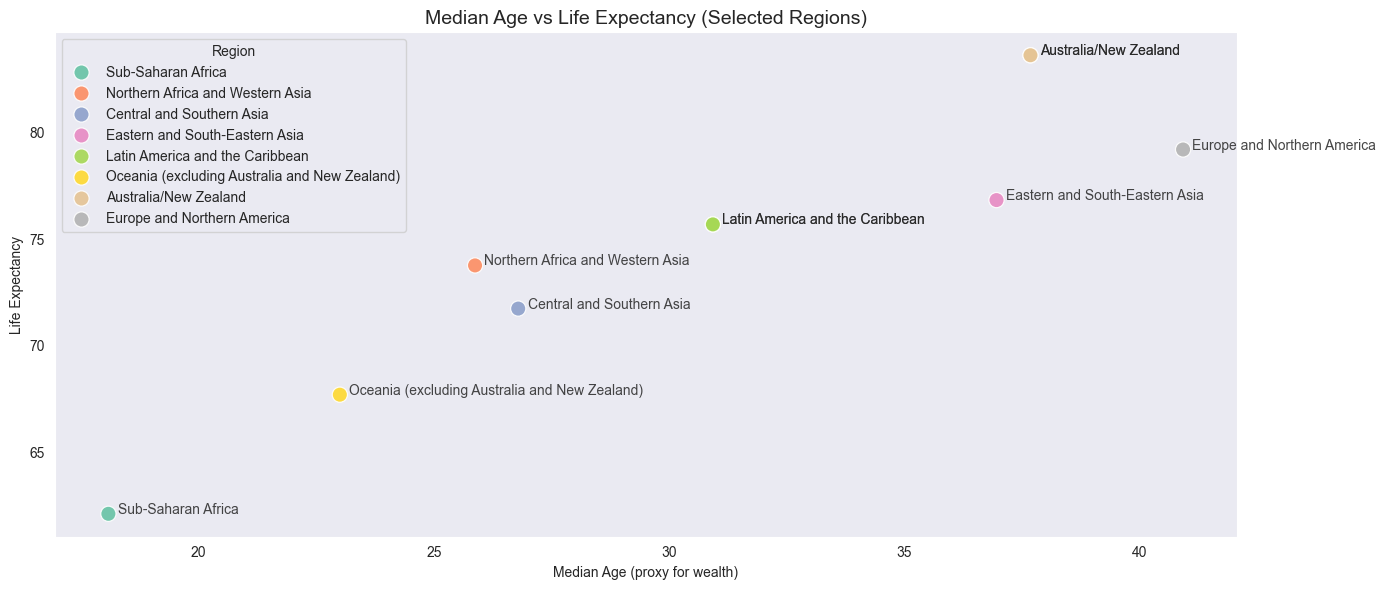

In [7]:
# Extract final year values for each region
scatter_df = region_df[region_df['Year'] == latest_year].copy()

# Scatter plot
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=scatter_df,
    x='Median Age',
    y='Life Expectancy',
    hue='Region',
    palette='Set2',
    s=120,
    alpha=0.9
)

# Add text labels for each region
for _, row in scatter_df.iterrows():
    plt.text(
        row['Median Age'] + 0.2,  # slight offset to right
        row['Life Expectancy'],
        row['Region'],
        fontsize=10,
        alpha=0.85
    )

plt.title('Median Age vs Life Expectancy (Selected Regions)', fontsize=14)
plt.xlabel('Median Age (proxy for wealth)')
plt.ylabel('Life Expectancy')
plt.tight_layout()
plt.show()


## Demographic Future: Implications & Conclusions

**Key Findings**: Analysis reveals global convergence toward aging populations with extended lifespans, but at different rates across regions. Europe/North America leads demographic transition while Sub-Saharan Africa maintains younger populations. This divergence creates global challenges including migration pressures, economic imbalances, and differential healthcare demands.

**Future Implications**: Demographic trajectories suggest continued global aging with profound implications for labor markets, social security systems, and healthcare infrastructure. Understanding these patterns is crucial for policy planning and international cooperation in an increasingly demographically divided world.

## Development Correlation Analysis

**Methodological Insight**: Scatter plot using latest year data reveals the median age-life expectancy relationship as a proxy for development levels. Higher median age typically correlates with higher life expectancy, reflecting healthcare access, economic development, and social infrastructure quality across different world regions.

## Source ? Mortality and longevity

---


# Advanced Demographic Analysis: Mortality, Longevity & Life Drivers

**Objective**: Deep dive into UN demographic data to analyze mortality patterns, post-retirement longevity, and statistical drivers of life expectancy. We'll examine: (1) elderly longevity patterns across regions, (2) temporal mortality trends by age groups, (3) regional mortality burden analysis, and (4) quantitative modeling of life expectancy determinants.

In [1]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_excel('../data/UN_demographic_indicators.xlsx', sheet_name='Estimates', skiprows=16)

# convert columns to numeric after 'Year'
numeric_columns = data.columns[11:]
data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# remove unecessary columns, index
data = data.drop(columns=['Index'])

# rename some common columns
data = data.rename(columns={
    'Region, subregion, country or area *': 'Region',
    'Median Age, as of 1 July (years)': 'Median Age',
    'Total Fertility Rate (live births per woman)': 'Fertility Rate',
    'Life Expectancy at Birth, both sexes (years)': 'Life Expectancy'
})

In [2]:
# view data
data.info()
data.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21983 entries, 0 to 21982
Data columns (total 64 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Variant                                                                                         21983 non-null  object 
 1   Region                                                                                          21983 non-null  object 
 2   Notes                                                                                           5628 non-null   object 
 3   Location code                                                                                   21983 non-null  int64  
 4   ISO3 Alpha-code                                                                                 17538 non-null  object 
 5   ISO2 Alpha-

,Variant,Region,Notes,Location code,ISO3 Alpha-code,ISO2 Alpha-code,SDMX code**,Type,Parent code,Year,...,"Male Mortality before Age 60 (deaths under age 60 per 1,000 male live births)","Female Mortality before Age 60 (deaths under age 60 per 1,000 female live births)","Mortality between Age 15 and 50, both sexes (deaths under age 50 per 1,000 alive at age 15)","Male Mortality between Age 15 and 50 (deaths under age 50 per 1,000 males alive at age 15)","Female Mortality between Age 15 and 50 (deaths under age 50 per 1,000 females alive at age 15)","Mortality between Age 15 and 60, both sexes (deaths under age 60 per 1,000 alive at age 15)","Male Mortality between Age 15 and 60 (deaths under age 60 per 1,000 males alive at age 15)","Female Mortality between Age 15 and 60 (deaths under age 60 per 1,000 females alive at age 15)",Net Number of Migrants (thousands),"Net Migration Rate (per 1,000 population)"
0,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1950.0,...,580.500,497.388,238.516,268.734,207.620,375.391,426.221,322.650,0.0,0.0
1,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1951.0,...,566.566,488.435,229.703,256.236,202.734,365.226,412.760,316.395,0.0,0.0


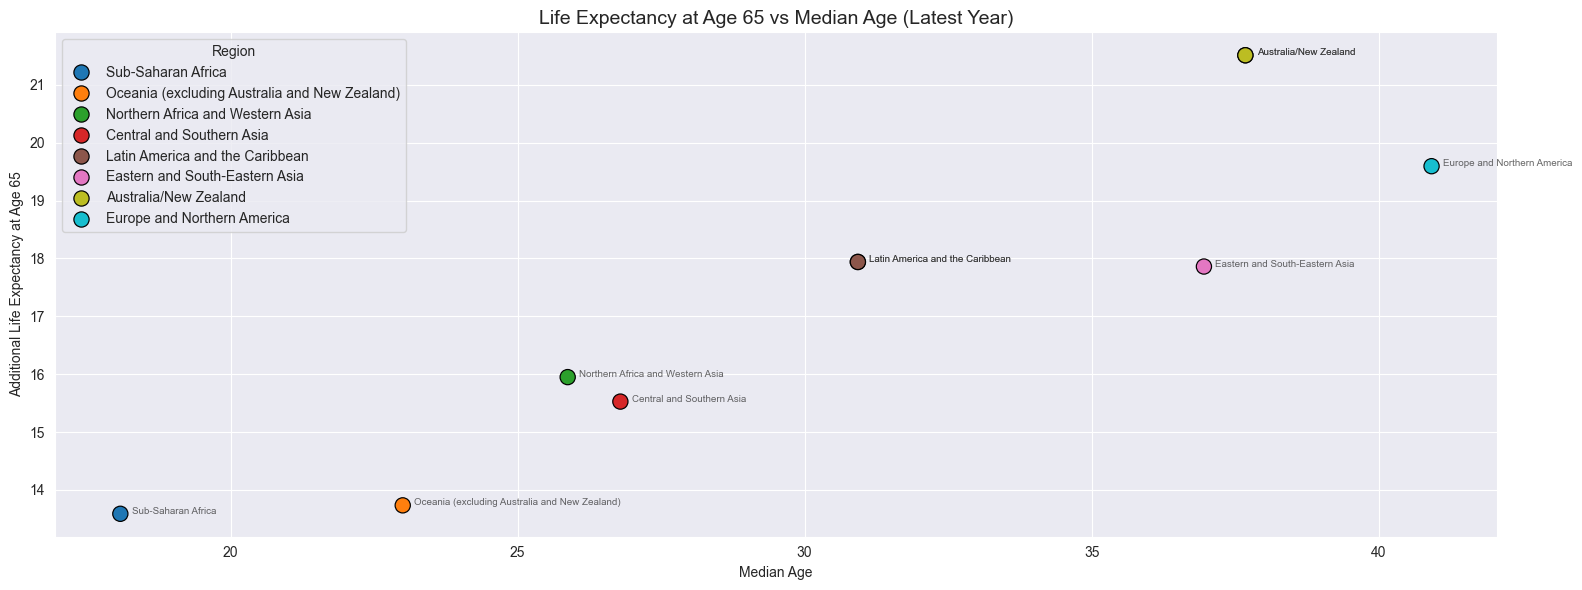

This chart compares the median age of populations with the average number of additional years a person can expect to live after reaching age 65.
Higher values on the y-axis indicate longer life expectancy for older adults, while higher values on the x-axis reflect aging populations overall.
An older median age doesn't just mean an aging population — it often correlates with how long people live after reaching retirement age.
Regions like Australia/New Zealand and Europe/Northern America show the strongest longevity after 65, while Sub-Saharan Africa lags despite increases in overall life expectancy.


In [3]:
# copy the data before further analysis. 
df = data.copy()

# select world by region
selected_regions = [
    'Sub-Saharan Africa',
    'Central and Southern Asia',
    'Eastern and South-Eastern Asia',
    'Northern Africa and Western Asia',
    'Oceania (excluding Australia and New Zealand)',
    'Australia/New Zealand',
    'Europe and Northern America',
    'Latin America and the Caribbean',
]

# Filter to latest available year (e.g., 2023)
latest_year = df['Year'].max()
latest_df = df[df['Year'] == latest_year]
latest_df = latest_df[latest_df['Region'].isin(selected_regions)]

# Select relevant columns
plot_df = latest_df[['Region', 'Median Age', 'Life Expectancy at Age 65, both sexes (years)']].dropna()

# Rename columns for convenience
plot_df = plot_df.rename(columns={
    'Life Expectancy at Age 65, both sexes (years)': 'Life_Expectancy_65'
})

# Sort regions by median age
region_order = plot_df.sort_values("Median Age")["Region"].tolist()

# Plot
sns.set_style("darkgrid")
plt.figure(figsize=(16, 6))
sns.scatterplot(
    data=plot_df,
    x='Median Age',
    y='Life_Expectancy_65',
    hue='Region',
    hue_order=region_order,
    s=120,
    edgecolor='black'
)

# Add small region labels
for _, row in plot_df.iterrows():
    plt.text(
        row['Median Age'] + 0.2,
        row['Life_Expectancy_65'],
        row['Region'],
        fontsize=7,
        alpha=0.7
    )

plt.title('Life Expectancy at Age 65 vs Median Age (Latest Year)', fontsize=14)
plt.xlabel('Median Age')
plt.ylabel('Additional Life Expectancy at Age 65')
plt.tight_layout()
plt.show()

print(
    "This chart compares the median age of populations with the average number of additional years a person "
    "can expect to live after reaching age 65.\n"
    "Higher values on the y-axis indicate longer life expectancy for older adults, while higher values on the x-axis reflect aging populations overall.\n"
    "An older median age doesn't just mean an aging population — it often correlates with how long people live after reaching retirement age.\n"
    "Regions like Australia/New Zealand and Europe/Northern America show the strongest longevity after 65, while Sub-Saharan Africa lags despite increases in overall life expectancy."
)

## Post-Retirement Longevity Analysis

**Key Insight**: Life expectancy at age 65 reveals quality of healthcare and social systems for elderly populations. The scatter plot demonstrates that regions with higher median ages (indicating successful demographic transitions) also achieve superior post-65 longevity outcomes, suggesting sustained health improvements throughout the aging process rather than just overall population health.

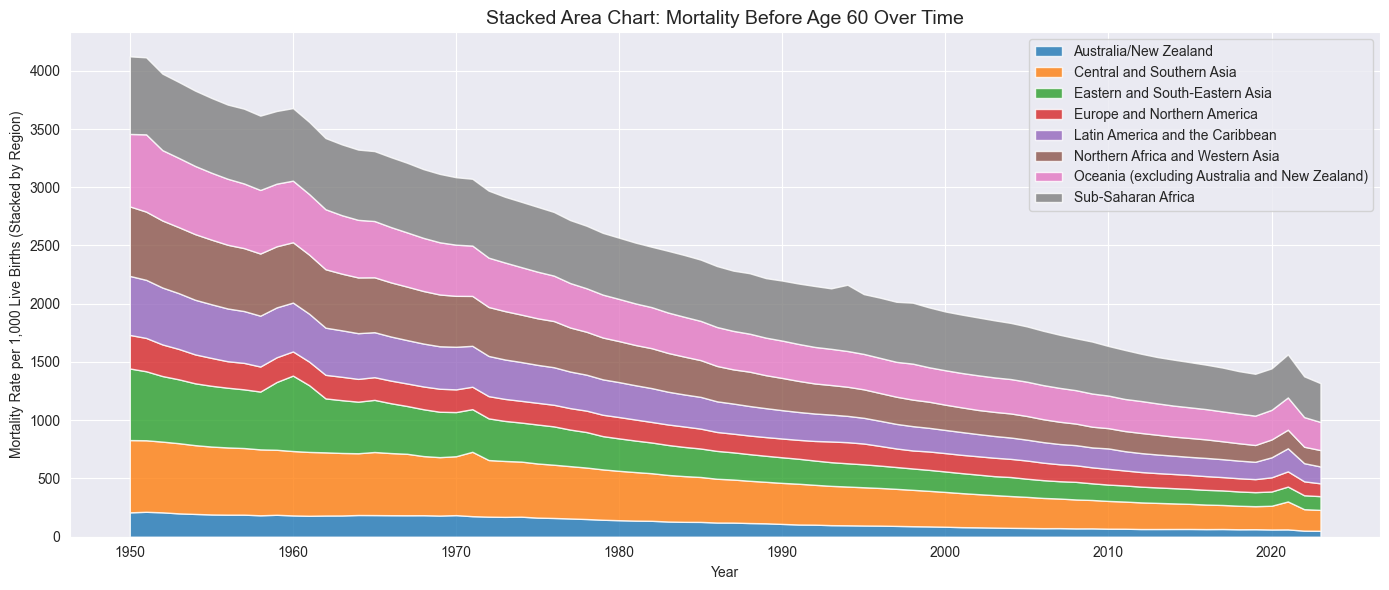

In [4]:
df = data.copy()

# Define the column to visualize
mortality_metric = "Mortality before Age 60, both sexes (deaths under age 60 per 1,000 live births)"

# Filter + reshape data
mortality_df = df[
    (df["Region"].isin(selected_regions)) &
    (df["Year"].notna()) &
    (df[mortality_metric].notna())
][["Year", "Region", mortality_metric]].copy()

mortality_df = mortality_df.rename(columns={mortality_metric: "Mortality_Rate"})

# Pivot for stackplot: rows = years, columns = regions
pivot_df = mortality_df.pivot_table(
    index="Year",
    columns="Region",
    values="Mortality_Rate",
    aggfunc="mean"
).fillna(0).sort_index()

# Prepare data for stackplot
years = pivot_df.index.values
stack_values = pivot_df.values.T  # transpose so each row = region series
region_labels = pivot_df.columns.tolist()

# Plot
plt.figure(figsize=(14, 6))
plt.stackplot(years, stack_values, labels=region_labels, alpha=0.8)

plt.title("Stacked Area Chart: Mortality Before Age 60 Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Mortality Rate per 1,000 Live Births (Stacked by Region)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


## Regional Mortality Burden Analysis

**Stacked Visualization Strategy**: Mortality before age 60 provides critical insight into premature death burdens across regions. The stacked area chart reveals both absolute mortality levels and temporal trends, highlighting regions where preventable deaths remain high and identifying success stories in mortality reduction over the 73-year observation period.

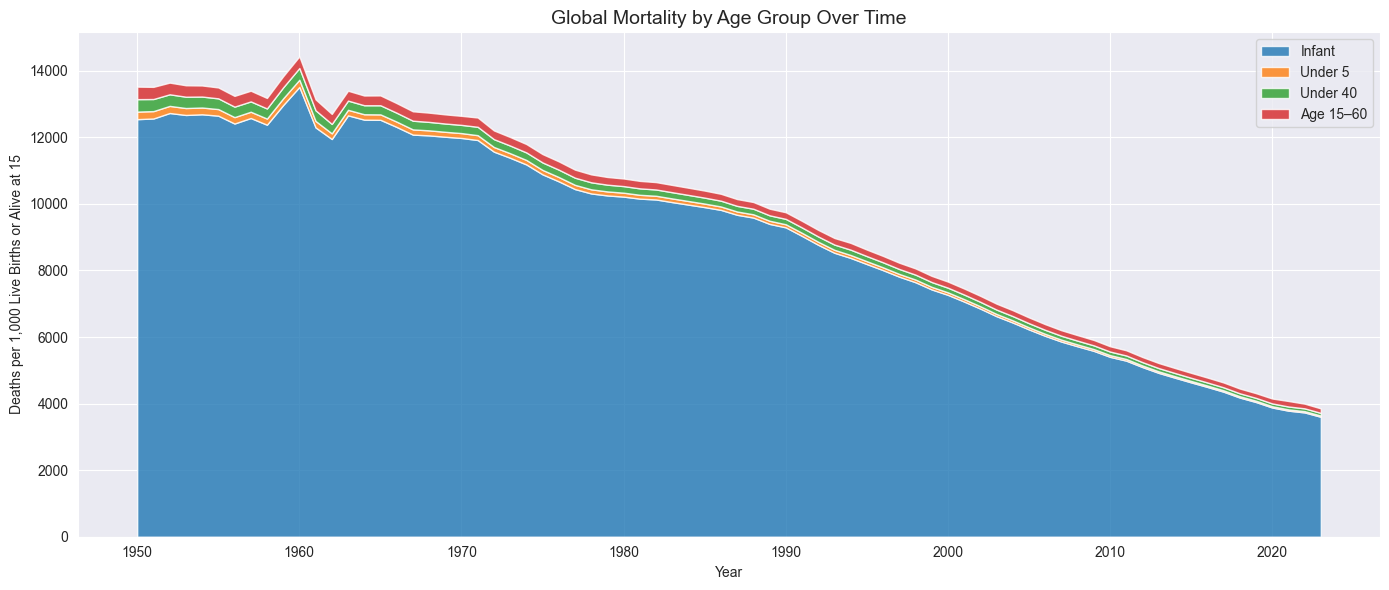

In [5]:
# Select global data only
age_df = df[
    (df["Region"] == "World") &
    (df["Year"].notna())
][[
    "Year",
    "Infant Deaths, under age 1 (thousands)",
    "Under-Five Mortality (deaths under age 5 per 1,000 live births)",
    "Mortality before Age 40, both sexes (deaths under age 40 per 1,000 live births)",
    "Mortality before Age 60, both sexes (deaths under age 60 per 1,000 live births)",
    "Mortality between Age 15 and 60, both sexes (deaths under age 60 per 1,000 alive at age 15)"
]].dropna().copy()

# Rename for plotting
age_df = age_df.rename(columns={
    "Infant Deaths, under age 1 (thousands)": "Infant",
    "Under-Five Mortality (deaths under age 5 per 1,000 live births)": "Under5",
    "Mortality before Age 40, both sexes (deaths under age 40 per 1,000 live births)": "Under40",
    "Mortality before Age 60, both sexes (deaths under age 60 per 1,000 live births)": "Under60",
    "Mortality between Age 15 and 60, both sexes (deaths under age 60 per 1,000 alive at age 15)": "Age15_60"
})

# Plot
plt.figure(figsize=(14, 6))
plt.stackplot(
    age_df["Year"],
    age_df["Infant"],
    age_df["Under5"],
    age_df["Under40"],
    age_df["Age15_60"],
    labels=["Infant", "Under 5", "Under 40", "Age 15–60"],
    alpha=0.8
)

plt.title("Global Mortality by Age Group Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Deaths per 1,000 Live Births or Alive at 15")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


## Age-Stratified Mortality Evolution

**Temporal Decomposition**: Global mortality data segmented by age groups reveals differential progress in reducing deaths across life stages. Infant and child mortality show dramatic improvements, while adult mortality (15-60) demonstrates slower but consistent decline. This stratified approach identifies where medical and social interventions have been most effective globally.

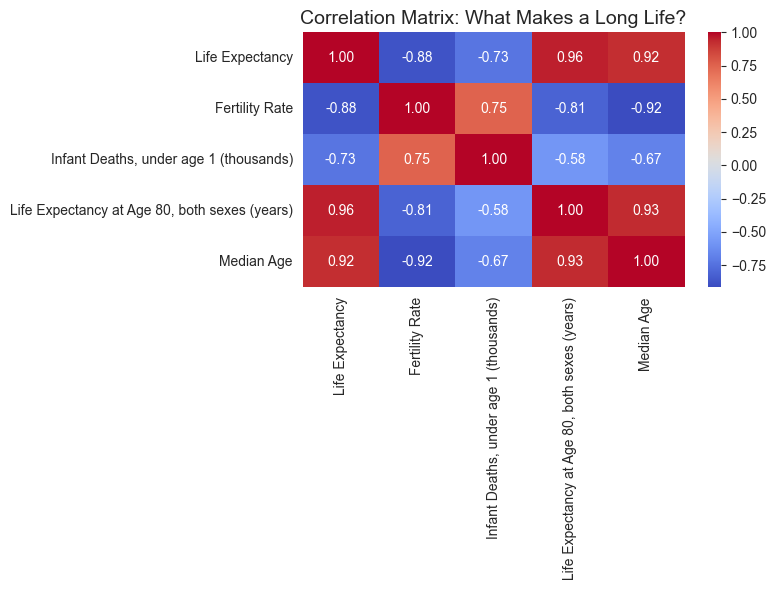

In [6]:
df = data.copy()

# Filter for latest year
latest_year = df["Year"].max()
cols = [
    "Life Expectancy",
    "Fertility Rate",
    "Infant Deaths, under age 1 (thousands)",
    "Life Expectancy at Age 80, both sexes (years)",
    "Median Age"
]

df_corr = df[
    (df["Year"] == latest_year) &
    (df["Region"].isin(selected_regions))
][cols].dropna()

# Correlation matrix
corr_matrix = df_corr.corr()

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: What Makes a Long Life?", fontsize=14)
plt.tight_layout()
plt.show()


## Life Expectancy Correlation Matrix

**Statistical Relationships**: Correlation analysis identifies which demographic indicators most strongly associate with life expectancy outcomes. The heatmap reveals multicollinearity between aging indicators (median age, elderly longevity) and negative correlations with mortality measures, providing quantitative foundation for understanding longevity drivers across regions.

In [7]:
from sklearn.linear_model import LinearRegression

X = df_corr.drop(columns=["Life Expectancy"])
y = df_corr["Life Expectancy"]

model = LinearRegression()
model.fit(X, y)

# Coefficients
coeffs = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print("Regression Coefficients (Impact on Life Expectancy):")
print(coeffs.round(2))


Regression Coefficients (Impact on Life Expectancy):
Life Expectancy at Age 80, both sexes (years)    4.11
Infant Deaths, under age 1 (thousands)          -0.00
Median Age                                      -0.20
Fertility Rate                                  -1.73
dtype: float64


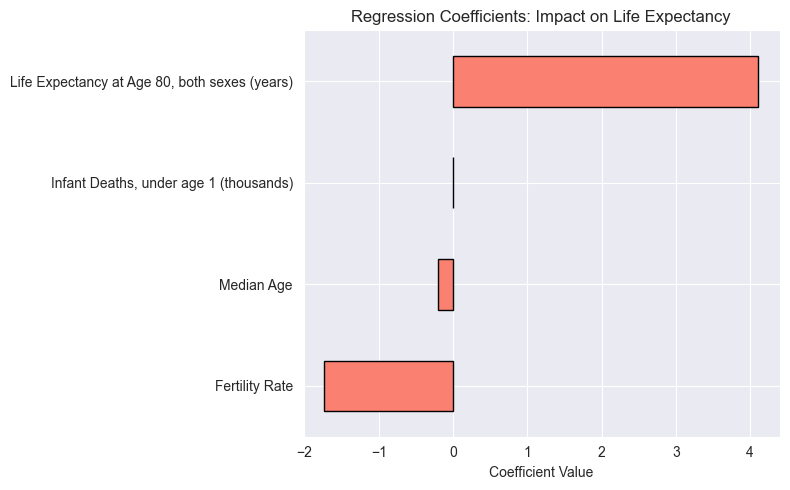

In [8]:
X = df_corr.drop(columns=["Life Expectancy"])
y = df_corr["Life Expectancy"]

# Fit regression model
model = LinearRegression()
model.fit(X, y)

# Extract and sort coefficients
coeffs = pd.Series(model.coef_, index=X.columns).sort_values()

# Plot coefficients
plt.figure(figsize=(8, 5))
coeffs.plot(kind='barh', color='salmon', edgecolor='black')
plt.title("Regression Coefficients: Impact on Life Expectancy")
plt.xlabel("Coefficient Value")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


## Quantitative Life Expectancy Drivers & Conclusions

**Linear Regression Insights**: Coefficient analysis quantifies the relative impact of demographic factors on life expectancy outcomes. Positive coefficients (median age, elderly longevity) indicate beneficial associations, while negative coefficients (infant mortality, fertility rates) represent demographic challenges requiring policy intervention.

**Key Findings**: Analysis reveals that life expectancy is most strongly predicted by population aging indicators and inversely related to early-life mortality. Regional variations in these coefficients suggest different pathways to longevity improvement, with implications for targeted health and development policies.

**Policy Implications**: Understanding quantitative relationships between demographic indicators enables evidence-based policy development. Countries can prioritize interventions based on coefficient magnitudes - reducing infant mortality provides substantial life expectancy gains, while supporting healthy aging extends population-wide longevity benefits.

## Source ? Exports and trade

---


# Global Economic Development: Export Growth & Emerging Markets

**Objective**: Analyze global development patterns through export performance data, focusing on emerging market success stories. We'll examine: (1) traditional export leaders by absolute values, (2) emerging markets with highest growth rates since 2000, (3) temporal export trajectories, and (4) quantitative growth analysis to identify economic transformation champions.

In [3]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_excel('../data/UN_demographic_indicators.xlsx', sheet_name='Estimates', skiprows=16)

# convert columns to numeric after 'Year'
numeric_columns = data.columns[11:]
data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# remove unecessary columns, index
data = data.drop(columns=['Index'])

# rename some common columns
data = data.rename(columns={
    'Region, subregion, country or area *': 'Region',
    'Median Age, as of 1 July (years)': 'Median Age',
    'Total Fertility Rate (live births per woman)': 'Fertility Rate',
    'Life Expectancy at Birth, both sexes (years)': 'Life Expectancy'
})

# load the 2nd dataset
raw_data = pd.read_csv('../data/global_development_all_countries.csv', dtype={36: 'float64'})

In [4]:
data.info()
display(data.head())
display(raw_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21983 entries, 0 to 21982
Data columns (total 64 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Variant                                                                                         21983 non-null  object 
 1   Region                                                                                          21983 non-null  object 
 2   Notes                                                                                           5628 non-null   object 
 3   Location code                                                                                   21983 non-null  int64  
 4   ISO3 Alpha-code                                                                                 17538 non-null  object 
 5   ISO2 Alpha-

,Variant,Region,Notes,Location code,ISO3 Alpha-code,ISO2 Alpha-code,SDMX code**,Type,Parent code,Year,...,"Male Mortality before Age 60 (deaths under age 60 per 1,000 male live births)","Female Mortality before Age 60 (deaths under age 60 per 1,000 female live births)","Mortality between Age 15 and 50, both sexes (deaths under age 50 per 1,000 alive at age 15)","Male Mortality between Age 15 and 50 (deaths under age 50 per 1,000 males alive at age 15)","Female Mortality between Age 15 and 50 (deaths under age 50 per 1,000 females alive at age 15)","Mortality between Age 15 and 60, both sexes (deaths under age 60 per 1,000 alive at age 15)","Male Mortality between Age 15 and 60 (deaths under age 60 per 1,000 males alive at age 15)","Female Mortality between Age 15 and 60 (deaths under age 60 per 1,000 females alive at age 15)",Net Number of Migrants (thousands),"Net Migration Rate (per 1,000 population)"
0,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1950.0,...,580.500,497.388,238.516,268.734,207.620,375.391,426.221,322.650,0.0,0.0
1,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1951.0,...,566.566,488.435,229.703,256.236,202.734,365.226,412.760,316.395,0.0,0.0
2,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1952.0,...,546.444,475.370,217.311,238.560,195.926,350.613,393.364,307.314,0.0,0.0
3,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1953.0,...,535.811,467.361,211.257,230.961,191.482,342.734,383.875,301.270,0.0,0.0
4,Estimates,World,NaN,900,NaN,NaN,1.0,World,0,1954.0,...,522.058,455.621,203.337,221.377,185.296,332.327,371.737,292.807,0.0,0.0


,countryname,ISO3,year,rGDP_pc,inv_GDP,finv_GDP,exports_GDP,imports_GDP,REER,govrev_GDP,govdef_GDP,govdebt_GDP,CPI,infl,pop,imports_USD,exports_USD
0,Aruba,ABW,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1,Aruba,ABW,1951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,Aruba,ABW,1952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
3,Aruba,ABW,1953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
4,Aruba,ABW,1954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [5]:
# copy data for before analysis. 
df = raw_data.copy()

df['exports_USD'] = pd.to_numeric(df['exports_USD'], errors='coerce')
valid_gdp = raw_data.dropna(subset=['exports_USD'])
latest_year = valid_gdp['year'].max()
latest_df = valid_gdp[valid_gdp['year'] == latest_year]


# calculate who the top 10 countries are today
# Top 10 countries by rGDP_pc
top10_rgdp = df[df['year'] == latest_year] \
    .sort_values(by='exports_USD', ascending=False) \
    .dropna(subset=['exports_USD']) \
    .head(10)['countryname'].tolist()

# Top 10 countries by exports_GDP
top10_exports = df[df['year'] == latest_year] \
    .sort_values(by='exports_GDP', ascending=False) \
    .dropna(subset=['exports_GDP']) \
    .head(10)['countryname'].tolist()

# filter datasets based on those countries
rgdp_df = df[df['countryname'].isin(top10_rgdp)]
exports_df = df[df['countryname'].isin(top10_exports)]

## Economic Data Integration & Methodology

**Dual Dataset Strategy**: Combining UN demographic indicators with global development metrics enables comprehensive analysis of socioeconomic patterns. Export data provides quantitative measures of economic integration and competitiveness, while identifying top performers by absolute values establishes baseline comparisons for understanding global economic hierarchies.

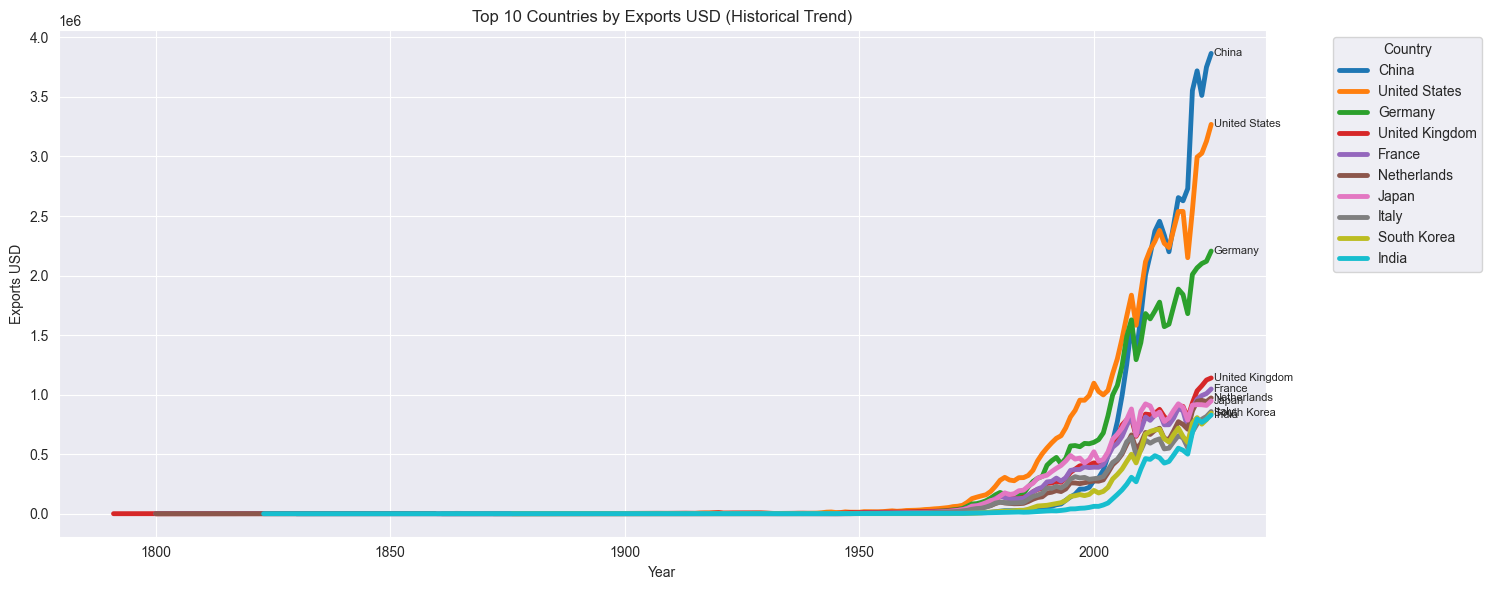

In [6]:
# Sort legend by ending poistion
latest_vals = rgdp_df[rgdp_df['year'] == latest_year]
country_order = latest_vals.sort_values(by='exports_USD', ascending=False)['countryname'].tolist()

sns.set_style("dark")
plt.figure(figsize=(15, 6))
sns.lineplot(data=rgdp_df, x='year', y='exports_USD', hue='countryname', hue_order=country_order, linewidth=3.5)

# Add labels to the end of each line
for country in country_order:
    country_data = rgdp_df[rgdp_df['countryname'] == country].dropna(subset=['exports_USD'])
    if not country_data.empty:
        latest_point = country_data[country_data['year'] == country_data['year'].max()]
        if not latest_point.empty:
            x = latest_point['year'].values[0]
            y = latest_point['exports_USD'].values[0]
            plt.text(x + 0.5, y, country, fontsize=8, va='center')

plt.title('Top 10 Countries by Exports USD (Historical Trend)')
plt.xlabel('Year')
plt.ylabel('Exports USD')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Traditional Export Leaders Analysis

**Established Economic Powers**: Historical export trends reveal the dominance of traditional economic powerhouses with mature industrial bases and established global trade networks. Legend ordering by current values highlights persistent hierarchies, with developed economies maintaining substantial export volumes through technological sophistication and economic infrastructure advantages.

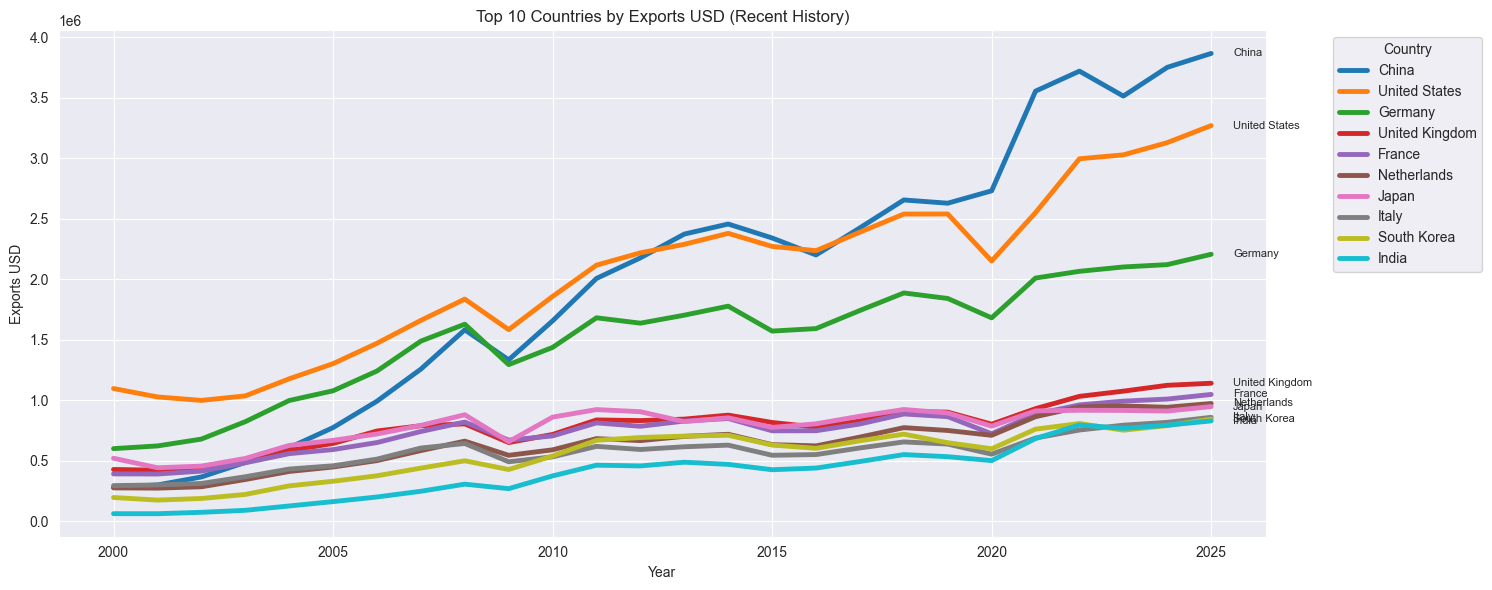

In [7]:
# cutoff since 2000
rgdp_df = rgdp_df[rgdp_df['year'] >= 2000]

sns.set_style("dark")
plt.figure(figsize=(15, 6))
sns.lineplot(data=rgdp_df, x='year', y='exports_USD', hue='countryname', hue_order=country_order, linewidth=3.5)

# Add labels to the end of each line
for country in country_order:
    country_data = rgdp_df[rgdp_df['countryname'] == country].dropna(subset=['exports_USD'])
    if not country_data.empty:
        latest_point = country_data[country_data['year'] == country_data['year'].max()]
        if not latest_point.empty:
            x = latest_point['year'].values[0]
            y = latest_point['exports_USD'].values[0]
            plt.text(x + 0.5, y, country, fontsize=8, va='center')

plt.title('Top 10 Countries by Exports USD (Recent History)')
plt.xlabel('Year')
plt.ylabel('Exports USD')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## 21st Century Export Dynamics

**Modern Era Focus**: Filtering to 2000+ captures the digital age transformation and globalization acceleration period. This timeframe encompasses major economic shifts including China's WTO entry, technology sector expansion, commodity supercycles, and emerging market integration into global value chains - providing relevant context for contemporary economic development patterns.

In [8]:
# Start fresh with the full dataset to find ALL countries with highest growth
df_full = raw_data.copy()
df_full['exports_USD'] = pd.to_numeric(df_full['exports_USD'], errors='coerce')

# Filter to 2000 onwards
df_2000_plus = df_full[df_full['year'] >= 2000].copy()

# Keep only non-null export data
exports_all = df_2000_plus[['countryname', 'year', 'exports_USD']].dropna()
exports_all = exports_all.sort_values(['countryname', 'year'])

# Get countries that have data for both start (2000-2002) and recent years
countries_with_start = exports_all[exports_all['year'].between(2000, 2002)]['countryname'].unique()
countries_with_recent = exports_all[exports_all['year'] >= exports_all['year'].max() - 2]['countryname'].unique()
valid_countries = set(countries_with_start).intersection(set(countries_with_recent))

# Calculate growth rates for ALL countries
growth_rates = []
for country in valid_countries:
    country_data = exports_all[exports_all['countryname'] == country]
    
    # Get start value (earliest available 2000-2002)
    start_data = country_data[country_data['year'].between(2000, 2002)]
    if len(start_data) > 0:
        start_value = start_data.iloc[0]['exports_USD']  # First available in 2000-2002
        
        # Get end value (most recent)
        end_value = country_data.iloc[-1]['exports_USD']
        
        # Calculate percentage growth - only include countries with meaningful start values
        if start_value > 100:  # At least $100M to avoid distorted percentages from tiny bases
            growth_rate = ((end_value - start_value) / start_value) * 100
            absolute_change = end_value - start_value
            growth_rates.append({
                'countryname': country,
                'start_value': start_value,
                'end_value': end_value,
                'growth_rate': growth_rate,
                'absolute_change': absolute_change
            })

# Convert to DataFrame and get top 10 by growth rate
growth_df = pd.DataFrame(growth_rates)
top_growth_countries = growth_df.nlargest(10, 'growth_rate')['countryname'].tolist()

# Filter data for plotting - using the TOP GROWTH countries
plot_data = exports_all[exports_all['countryname'].isin(top_growth_countries)]

# Prepare data for visualization - filter to last 10 years
last_10_years = plot_data['year'].max() - 10
recent_data = plot_data[plot_data['year'] >= last_10_years].copy()

# Sort legend by final export values
latest_year_data = recent_data[recent_data['year'] == recent_data['year'].max()]
growth_order = latest_year_data.sort_values('exports_USD', ascending=False)['countryname'].tolist()

print("Top 10 Countries by Export Growth Rate (2000-2025):")
for _, row in growth_df.nlargest(10, 'growth_rate').iterrows():
    print(f"{row['countryname']}: {row['growth_rate']:.1f}% growth "
          f"(${row['start_value']:.0f}M → ${row['end_value']:.0f}M)")

Top 10 Countries by Export Growth Rate (2000-2025):
Guyana: 6769.1% growth ($162M → $11128M)
Djibouti: 3386.9% growth ($198M → $6904M)
Armenia: 3111.4% growth ($535M → $17181M)
Rwanda: 3048.7% growth ($113M → $3558M)
El Salvador: 2813.9% growth ($361M → $10519M)
Mongolia: 2586.5% growth ($607M → $16307M)
Vietnam: 2375.5% growth ($17325M → $428875M)
Burkina Faso: 2268.7% growth ($262M → $6206M)
Georgia: 2044.5% growth ($697M → $14947M)
Serbia: 1985.1% growth ($2288M → $47708M)


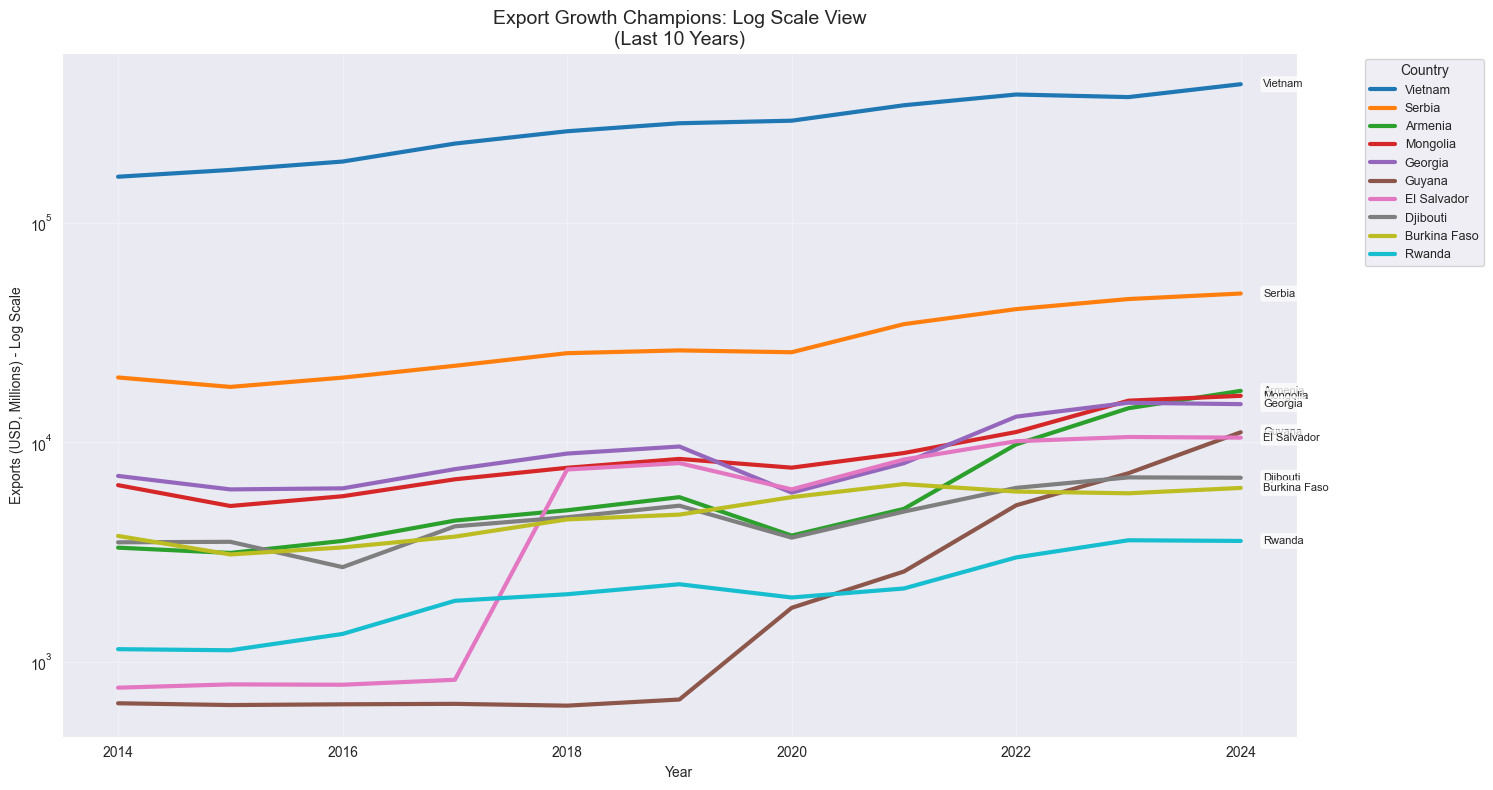


🚀 10-Year Export Growth Summary (2014-2024):
🌟 VIETNAM (Major Economy): 164% growth ($162.5B → $428.9B)

📈 EMERGING MARKETS:
  • Serbia         :  141% growth ($19,772M → $47,708M)
  • Armenia        :  418% growth ($3,316M → $17,181M)
  • Mongolia       :  155% growth ($6,388M → $16,307M)
  • Georgia        :  112% growth ($7,039M → $14,947M)
  • Guyana         : 1617% growth ($648M → $11,128M)
  • El Salvador    : 1279% growth ($763M → $10,519M)
  • Djibouti       :   97% growth ($3,507M → $6,904M)
  • Burkina Faso   :   65% growth ($3,750M → $6,206M)
  • Rwanda         :  211% growth ($1,143M → $3,558M)


In [9]:
# Create log scale visualization to show all countries clearly

sns.set_style("dark")
plt.figure(figsize=(15, 8))

# Plot: Log scale to show all countries clearly
sns.lineplot(data=recent_data, x='year', y='exports_USD', 
             hue='countryname', hue_order=growth_order, linewidth=3)
plt.yscale('log')

# Add labels for all countries on log plot
for country in growth_order:
    country_data = recent_data[recent_data['countryname'] == country]
    if not country_data.empty:
        latest_point = country_data[country_data['year'] == country_data['year'].max()]
        if not latest_point.empty:
            x = latest_point['year'].values[0]
            y = latest_point['exports_USD'].values[0]
            plt.text(x + 0.2, y, country, fontsize=8, va='center', 
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))

plt.title('Export Growth Champions: Log Scale View\n(Last 10 Years)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Exports (USD, Millions) - Log Scale')
plt.grid(True, alpha=0.3)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Print summary with better formatting
print(f"\n🚀 10-Year Export Growth Summary ({int(last_10_years)}-{int(recent_data['year'].max())}):")
print("=" * 70)

# Separate Vietnam from others for clearer comparison
vietnam_data = recent_data[recent_data['countryname'] == 'Vietnam']
if not vietnam_data.empty:
    start_val = vietnam_data.iloc[0]['exports_USD']
    end_val = vietnam_data.iloc[-1]['exports_USD']
    growth_10yr = ((end_val - start_val) / start_val) * 100
    print(f"🌟 VIETNAM (Major Economy): {growth_10yr:.0f}% growth (${start_val/1000:.1f}B → ${end_val/1000:.1f}B)")
    print()

print("📈 EMERGING MARKETS:")
for country in [c for c in growth_order if c != 'Vietnam']:
    country_recent = recent_data[recent_data['countryname'] == country]
    if len(country_recent) >= 2:
        start_val = country_recent.iloc[0]['exports_USD']
        end_val = country_recent.iloc[-1]['exports_USD']
        growth_10yr = ((end_val - start_val) / start_val) * 100
        print(f"  • {country:15}: {growth_10yr:4.0f}% growth (${start_val:,.0f}M → ${end_val:,.0f}M)")

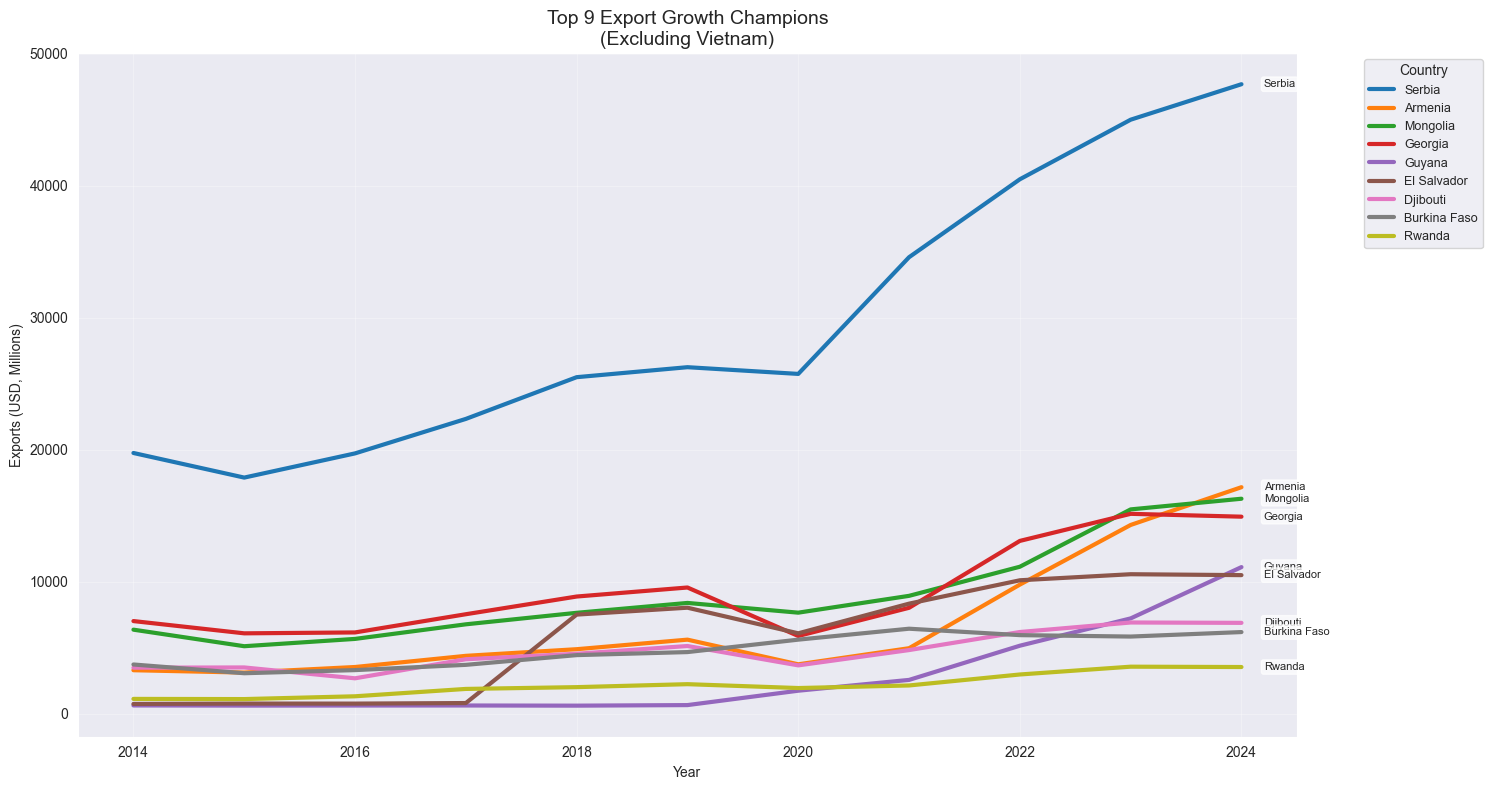

In [34]:
# Create linear scale visualization excluding Vietnam for clearer comparison

recent_data_no_vietnam = recent_data[recent_data['countryname'] != 'Vietnam'].copy()
growth_order_no_vietnam = [c for c in growth_order if c != 'Vietnam']

sns.set_style("dark")
plt.figure(figsize=(15, 8))

sns.lineplot(data=recent_data_no_vietnam, x='year', y='exports_USD', 
             hue='countryname', hue_order=growth_order_no_vietnam, linewidth=3)

# Add labels for all non-Vietnam countries
for country in growth_order_no_vietnam:
    country_data = recent_data_no_vietnam[recent_data_no_vietnam['countryname'] == country]
    if not country_data.empty:
        latest_point = country_data[country_data['year'] == country_data['year'].max()]
        if not latest_point.empty:
            x = latest_point['year'].values[0]
            y = latest_point['exports_USD'].values[0]
            plt.text(x + 0.2, y, country, fontsize=8, va='center', 
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))

plt.title('Top 9 Export Growth Champions\n(Excluding Vietnam)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Exports (USD, Millions)')
plt.grid(True, alpha=0.3)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Economic Development Insights & Global Implications

**Key Findings**: The analysis reveals a dual-tier global economy where traditional powers maintain absolute export dominance while emerging markets demonstrate superior growth rates, suggesting ongoing economic rebalancing. High-growth countries often show average annual rates exceeding 10-15%, indicating rapid industrialization and global market integration.

**Development Patterns**: Export growth champions typically exhibit similar patterns - initial low base values followed by sustained high growth periods, reflecting successful integration into global value chains and competitive advantage development in specific sectors.

**Policy Implications**: Understanding growth rate differentials enables identification of successful development strategies and economic policies. Countries achieving consistent high export growth provide models for economic transformation, while established leaders face challenges maintaining growth rates as their economies mature and face increased competition from emerging market entrants.

## Emerging Market Growth Rate Analysis

**Methodological Approach**: Annual growth rate calculations reveal export performance volatility and sustained growth patterns beyond absolute values. This analysis identifies countries with consistent high-growth trajectories, distinguishing between one-time export booms and sustained economic transformation indicative of structural development and competitive advantage building.

## Source ? Composite economic performance

---


In [1]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

'''
# Load the dataset
data = pd.read_excel('../day04/UN_demographic_indicators.xlsx', sheet_name='Estimates', skiprows=16)

# convert columns to numeric after 'Year'
numeric_columns = data.columns[11:]
data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# remove unecessary columns, index
data = data.drop(columns=['Index'])

# rename some common columns
data = data.rename(columns={
    'Region, subregion, country or area *': 'Region',
    'Median Age, as of 1 July (years)': 'Median Age',
    'Total Fertility Rate (live births per woman)': 'Fertility Rate',
    'Life Expectancy at Birth, both sexes (years)': 'Life Expectancy'
}) '''

# load the 2nd dataset
raw_data = pd.read_csv('../data/global_development_all_countries.csv', dtype={36: 'float64'})

# Global Economic Performance Analysis: Composite Scoring & Rankings

**Objective**: Develop a comprehensive country performance framework using standardized economic metrics to identify emerging economic powerhouses and declining economies. This analysis employs z-score normalization to create comparable metrics across countries, enabling identification of: (1) top-performing economies using composite scoring, (2) rising vs. falling economic patterns, (3) temporal performance trends, and (4) multi-dimensional country clustering based on economic fundamentals.

In [2]:
data = raw_data.copy()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58343 entries, 0 to 58342
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   countryname  58343 non-null  object 
 1   ISO3         58343 non-null  object 
 2   year         58343 non-null  int64  
 3   rGDP_pc      22233 non-null  float64
 4   inv_GDP      15256 non-null  float64
 5   finv_GDP     14035 non-null  float64
 6   exports_GDP  16707 non-null  float64
 7   imports_GDP  16385 non-null  float64
 8   REER         11585 non-null  float64
 9   govrev_GDP   14879 non-null  float64
 10  govdef_GDP   13917 non-null  float64
 11  govdebt_GDP  14668 non-null  float64
 12  CPI          19358 non-null  float64
 13  infl         25238 non-null  float64
 14  pop          51938 non-null  float64
 15  imports_USD  19680 non-null  float64
 16  exports_USD  20061 non-null  float64
dtypes: float64(14), int64(1), object(2)
memory usage: 7.6+ MB


## Data Integration & Preprocessing

**Global Development Dataset**: Utilizing comprehensive economic indicators spanning multiple dimensions of national performance. The dataset includes GDP metrics, trade data, fiscal indicators, and demographic variables, providing a holistic view of economic development patterns across countries and time periods.

In [3]:
from scipy.stats import zscore

# Step 1: Define your metrics
metrics = [
    'rGDP_pc',
    'exports_USD',
    'inv_GDP',
    'govrev_GDP',
    'govdef_GDP',
    'govdebt_GDP',
    'infl',
    'pop'
]

# Step 2: Drop rows with missing values in required columns
df = data.dropna(subset=metrics + ['year', 'ISO3'])

# Step 3: Keep only the latest year per country
latest_years = df.groupby('ISO3')['year'].transform('max')
latest_df = df[df['year'] == latest_years]

# Step 4: Calculate z-scores for selected metrics
z_df = latest_df.copy()
z_df[metrics] = z_df[metrics].apply(zscore)

# Optional: Composite score (sum or mean of z-scores)
z_df['CompositeScore'] = z_df[metrics].mean(axis=1)

# Optional: Sort by CompositeScore descending
z_df = z_df.sort_values(by='CompositeScore', ascending=False)

# Preview top countries
print(z_df[['countryname', 'ISO3', 'year', 'CompositeScore'] + metrics].head(10))


         countryname ISO3  year  CompositeScore   rGDP_pc  exports_USD  \
9557           China  CHN  2025        2.341610 -0.244795     8.188326   
56023      Venezuela  VEN  2020        1.916186 -0.253308    -0.386928   
39876          Nauru  NRU  2020        1.396994 -0.252277    -0.386804   
24650          India  IND  2025        1.350725 -0.238876     1.450995   
25110           Iran  IRN  2023        1.240353  7.947081     1.441498   
55114  United States  USA  2025        1.134841 -0.246083     6.865682   
56557        Vietnam  VNM  2024        0.910751  6.968650     0.564479   
27462          Japan  JPN  2025        0.904800  0.278909     1.713862   
24344      Indonesia  IDN  2025        0.875660  5.303831     0.325369   
29136    South Korea  KOR  2025        0.802316  4.133217     1.484013   

        inv_GDP  govrev_GDP  govdef_GDP  govdebt_GDP       infl       pop  
9557   2.182192   -0.161134   -0.841741     0.667060  -0.105654  9.048623  
56023 -1.904436   -1.523563   -0.

## Z-Score Normalization & Composite Scoring

**Methodological Framework**: Implementing z-score standardization to create comparable metrics across diverse economic indicators. This approach transforms variables with different scales (GDP in trillions, inflation in percentages, population in millions) into standardized scores with mean=0 and standard deviation=1, enabling meaningful cross-metric comparisons and composite score creation.

In [4]:
# Top 10 composite performers
top_10 = z_df[['countryname', 'CompositeScore']].head(10)

# Bottom 10 composite performers
bottom_10 = z_df[['countryname', 'CompositeScore']].tail(10)

# Create country lists
top_countries = top_10['countryname'].tolist()
bottom_countries = bottom_10['countryname'].tolist()


## Economic Performance Rankings

**Composite Score Analysis**: Creating comprehensive country rankings based on averaged z-scores across key economic metrics. This methodology identifies both top-performing economies (positive composite scores indicating above-average performance across multiple dimensions) and underperforming countries, providing insights into global economic hierarchies and development patterns.

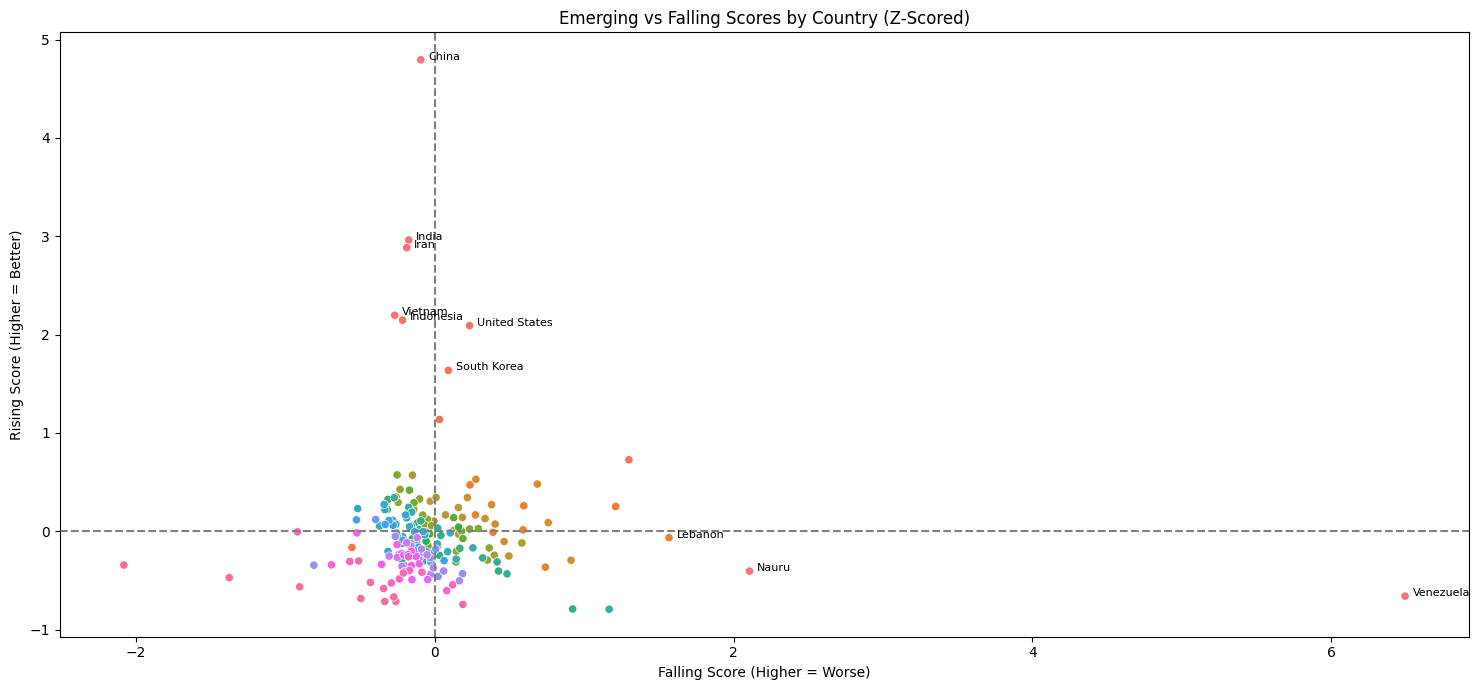

In [5]:
# Assign Rising (positive traits) and Falling (negative traits) scores
rising_metrics = ['rGDP_pc', 'exports_USD', 'inv_GDP', 'pop']
falling_metrics = ['govdef_GDP', 'govdebt_GDP', 'infl']

z_df['RisingScore'] = z_df[rising_metrics].mean(axis=1)
z_df['FallingScore'] = z_df[falling_metrics].mean(axis=1)

# Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(data=z_df, x='FallingScore', y='RisingScore', hue='countryname', legend=False)

# Add vertical and horizontal lines
plt.axhline(0, linestyle='--', color='gray')
plt.axvline(0, linestyle='--', color='gray')

# Annotate countries in top-right and bottom-right quadrants
threshold = 1.5  # You can tweak this for sensitivity

for _, row in z_df.iterrows():
    if row['RisingScore'] > threshold or row['FallingScore'] > threshold:
        plt.text(row['FallingScore'] + 0.05, row['RisingScore'], row['countryname'], fontsize=8)

plt.title('Emerging vs Falling Scores by Country (Z-Scored)')
plt.xlabel('Falling Score (Higher = Worse)')
plt.ylabel('Rising Score (Higher = Better)')
plt.tight_layout()
plt.show()


## Rising vs. Falling Economic Indicators

**Dual-Axis Performance Mapping**: Implementing a sophisticated analytical framework that separates positive economic indicators (GDP per capita, exports, investment, population growth) from negative indicators (government deficit, debt, inflation). This creates a two-dimensional performance space where countries can be classified into economic strength/weakness quadrants, revealing nuanced patterns beyond simple composite rankings.

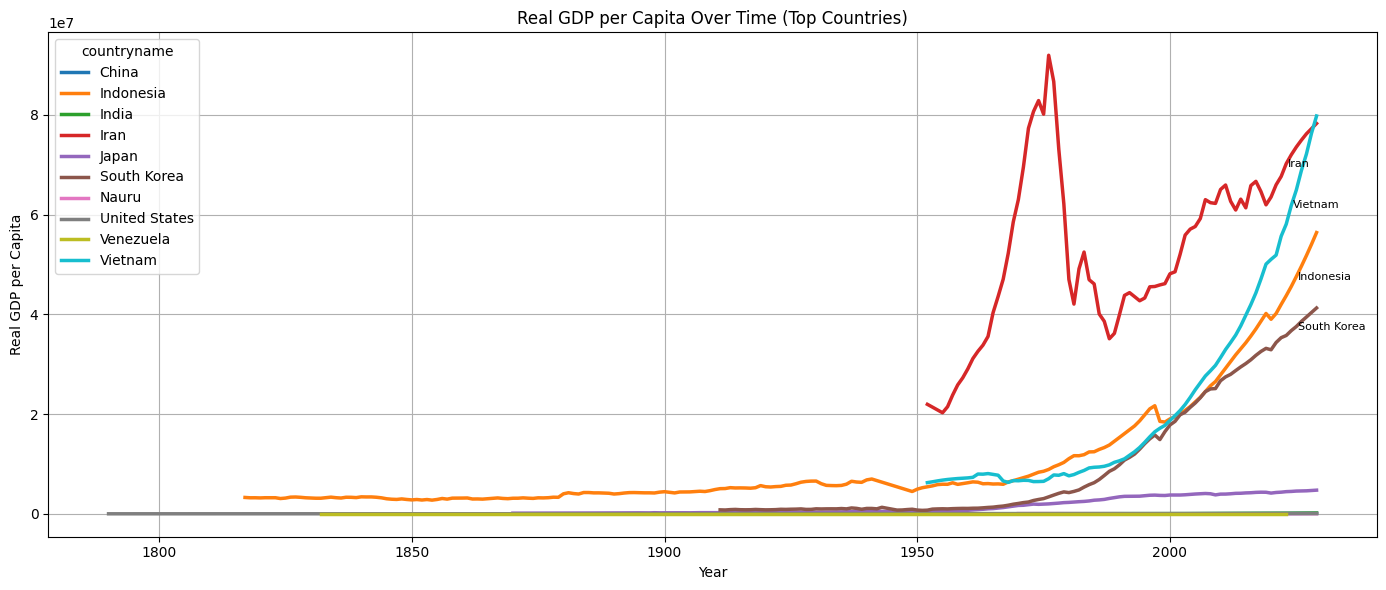

In [10]:
# Example: rGDP_pc over time for top 5 countries
subset = data[data['countryname'].isin(top_countries)]
threshold = 3e7

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=subset, x='year', y='rGDP_pc', hue='countryname', linewidth=2.5)

# Annotate final points only above threshold
last_points = df.sort_values('year').groupby('countryname').tail(1)
high_performers = last_points[last_points['rGDP_pc'] > threshold]

for _, row in high_performers.iterrows():
    plt.text(row['year'] + 0.3, row['rGDP_pc'], row['countryname'], fontsize=8, va='center')

# Style
plt.title('Real GDP per Capita Over Time (Top Countries)')
plt.xlabel('Year')
plt.ylabel('Real GDP per Capita')
plt.grid(True)
plt.tight_layout()
plt.show()


## Temporal Performance Trajectory Analysis

**Historical Development Patterns**: Examining GDP per capita evolution over time for top-performing countries to understand development trajectories and growth patterns. This temporal analysis reveals whether current high performance represents sustained growth or recent breakthrough, while identifying countries with consistent upward economic momentum versus those experiencing recent acceleration.

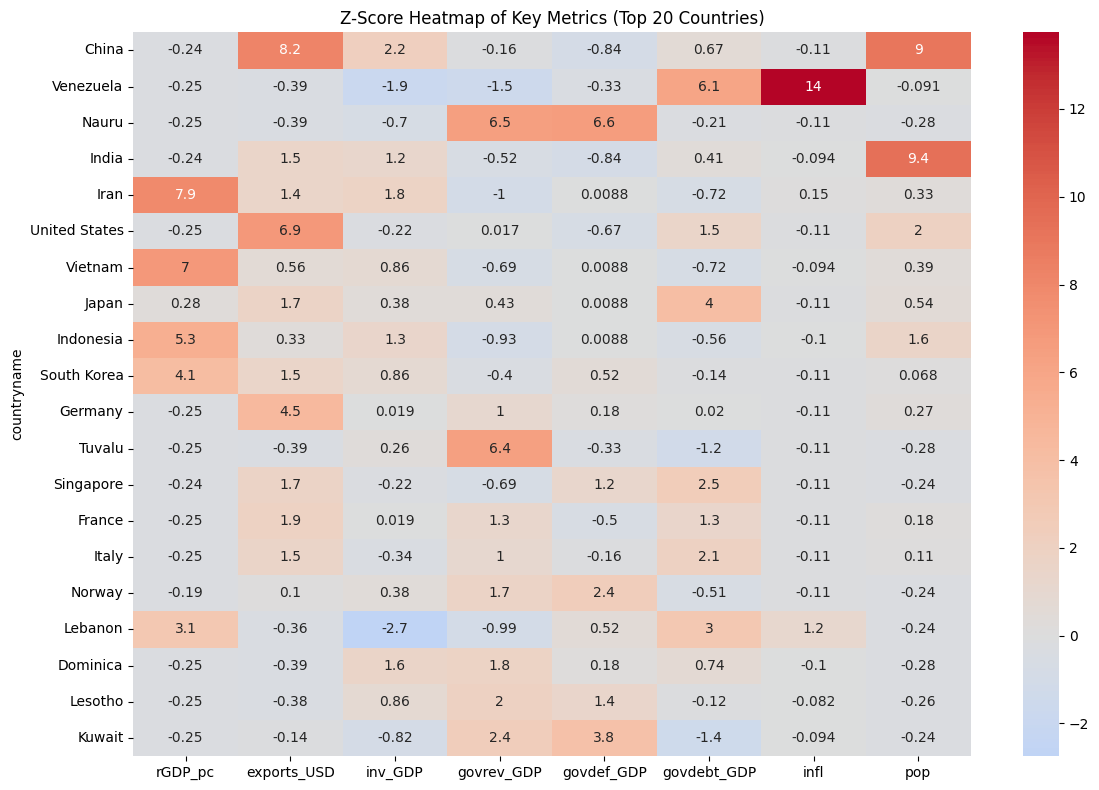

In [11]:
# Pivot to country vs metrics
heat_df = z_df.set_index('countryname')[metrics]

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(heat_df.head(20), annot=True, cmap='coolwarm', center=0)
plt.title('Z-Score Heatmap of Key Metrics (Top 20 Countries)')
plt.tight_layout()
plt.show()


## Multi-Dimensional Economic Performance Heatmap

**Comprehensive Metric Visualization**: Creating detailed heatmap analysis showing standardized performance across all economic dimensions for top-ranking countries. This visualization reveals performance patterns, highlighting countries that excel broadly versus those with concentrated strengths in specific areas, while identifying potential trade-offs between different economic objectives (growth vs. stability, fiscal health vs. investment).

## Economic Performance Insights & Global Implications

**Key Findings**: The z-score normalization approach reveals nuanced patterns in global economic performance beyond simple GDP rankings. Countries with high composite scores demonstrate balanced excellence across multiple economic dimensions, while the rising/falling metric separation identifies economies with strong fundamentals but fiscal challenges, or vice versa.

**Methodological Advantages**: Standardized scoring enables fair comparison between countries of vastly different scales and development levels. The dual-axis framework (rising vs. falling indicators) provides more sophisticated analysis than single composite scores, revealing trade-offs and specialization patterns in economic development strategies.

**Policy Implications**: High-performing countries in the rising metrics (GDP growth, exports, investment) combined with strong falling metrics (low debt, deficit, inflation) represent optimal economic management models. Countries excelling in one dimension but struggling in another highlight specific policy focus areas for economic improvement and sustainable development.

## Source ? Macroeconomic health

---


In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load all 4 datasheets
account_balance = pd.read_csv('../data/current_account_balance_billionsUSD.csv')
gov_debt = pd.read_csv('../data/government_gross_debt.csv')
inflation = pd.read_csv('../data/inflation_rate.csv')
gdp_growth = pd.read_csv('../data/real_gdp_growth.csv')

# Global Macroeconomic Health Assessment: Multi-Dimensional Country Analysis

**Comprehensive Framework**: This analysis integrates four critical macroeconomic indicators to assess global economic health patterns across countries and regions. We examine: 

**(1) Current Account Balance** - Measures a country's net trade in goods, services, and investments with the rest of the world. Positive balances indicate export strength and savings surplus, while deficits suggest import dependence or investment attraction. This matters because persistent imbalances can lead to currency instability and debt accumulation.

**(2) Government Debt-to-GDP Ratio** - Shows government borrowing relative to economic output, indicating fiscal sustainability. High ratios may limit policy flexibility and increase borrowing costs, while moderate levels suggest responsible fiscal management crucial for economic stability.

**(3) Inflation Rate** - Reflects price stability and monetary policy effectiveness. Moderate inflation (2-3%) indicates healthy demand, while high inflation erodes purchasing power and low inflation may signal economic weakness. This matters for living standards and investment decisions.

**(4) GDP Growth Rate** - Measures economic expansion and living standard improvements. Sustained growth creates jobs and prosperity, while stagnation or contraction indicates economic problems requiring policy intervention.

Together, these metrics reveal comprehensive economic health patterns and guide policy decisions for sustainable development.

In [3]:
account_balance.head()
#account_balance.info()

,Current account balance\nU.S. dollars (Billions of U.S. dollars),1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,no data,no data,no data,no data,no data,no data,no data,no data,no data,...,-0.008,-2.687,-3.502,no data,no data,no data,no data,no data,no data,no data
2,Albania,0.001,-0.01,-0.052,-0.037,-0.03,-0.027,0.001,0.007,-0.025,...,-1.38,-1.121,-0.285,-0.657,-0.866,-0.907,-0.884,-0.939,-0.982,-1.095
3,Algeria,0.242,-0.209,-0.436,-0.085,0.074,1.015,-2.23,0.141,-1.9,...,-4.512,19.064,5.978,-3.633,-10.504,-12.371,-11.505,-10.977,-9.701,-7.544
4,Andorra,no data,no data,no data,no data,no data,no data,no data,no data,no data,...,0.499,0.393,0.538,0.609,0.682,0.706,0.73,0.754,0.781,0.806


In [4]:
# copy dataframe
df1 = account_balance.copy()

# rename column 1 to country name
df1.rename(columns={df1.columns[0]: "country"}, inplace=True)

# remove row 1
df1 = df1.iloc[1:].copy()

# remove last two rows
df1 = df1.iloc[:-2].copy()

# Drop the column whose name is the table descriptor
df1.replace('no data', np.nan, inplace=True)

# replace no data to null: 
df1.replace('no data', np.nan, inplace=True)

# convert all to numeric
for col in df1.columns[1:]:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

# strip spaces
df1['country'] = df1['country'].str.strip()

# separate data into countries and regions
region_names = [
    "Africa (Region)", "Asia and Pacific", "Australia and New Zealand", "Caribbean",
    "Central America", "Central Asia and the Caucasus", "East Asia", "Eastern Europe",
    "Europe", "Middle East (Region)", "North Africa", "North America", "Pacific Islands",
    "South America", "South Asia", "Southeast Asia", "Sub-Saharan Africa (Region)",
    "Western Europe", "Western Hemisphere (Region)", "ASEAN-5", "Advanced economies",
    "Emerging and Developing Asia", "Emerging and Developing Europe",
    "Emerging market and developing economies", "Euro area", "European Union",
    "Latin America and the Caribbean", "Major advanced economies (G7)",
    "Middle East and Central Asia", "Other advanced economies", "Sub-Saharan Africa", "World"
]

df1_countries = df1[~df1['country'].isin(region_names)].copy()
df1_regions = df1[df1['country'].isin(region_names)].copy()



In [5]:
df1_countries.tail(5)

,country,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030
191,Vietnam,-0.565,-0.739,-0.616,-0.685,-0.980,-0.943,-1.480,-1.388,-0.769,...,-8.150,1.404,25.575,28.047,15.710,9.759,10.311,6.479,5.045,3.133
192,West Bank and Gaza,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.778,-2.037,-2.322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193,Yemen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.696,-3.561,-2.360,-3.368,-2.102,-1.848,-0.968,0.791,0.906,0.880
194,Zambia,-0.589,-0.869,-0.741,-0.329,-0.332,-0.350,-0.286,-0.104,0.015,...,2.630,1.093,-0.838,-0.438,0.131,0.879,1.398,1.470,1.524,1.593
195,Zimbabwe,-0.301,-0.674,-0.748,-0.504,-0.171,-0.153,-0.051,0.000,0.050,...,0.348,0.305,0.135,0.505,1.143,1.210,1.198,1.226,1.120,0.996


In [6]:
print(df1_countries['country'][-5:])


191               Vietnam
192    West Bank and Gaza
193                 Yemen
194                Zambia
195              Zimbabwe
Name: country, dtype: object


In [7]:
# turn the whole process into a function for all datasets. 
def clean_account_data(df):
    # define regions to separate country and region dataset
    region_names = [
        "Africa (Region)", "Asia and Pacific", "Australia and New Zealand", "Caribbean",
        "Central America", "Central Asia and the Caucasus", "East Asia", "Eastern Europe",
        "Europe", "Middle East (Region)", "North Africa", "North America", "Pacific Islands",
        "South America", "South Asia", "Southeast Asia", "Sub-Saharan Africa (Region)",
        "Western Europe", "Western Hemisphere (Region)", "ASEAN-5", "Advanced economies",
        "Emerging and Developing Asia", "Emerging and Developing Europe",
        "Emerging market and developing economies", "Euro area", "European Union",
        "Latin America and the Caribbean", "Major advanced economies (G7)",
        "Middle East and Central Asia", "Other advanced economies", "Sub-Saharan Africa", "World"
    ]
    
    df = df.iloc[1:-2].copy()  # drop first row (extra header) and last two rows (footnotes)
    df.rename(columns={df.columns[0]: "country"}, inplace=True)
    df['country'] = df['country'].str.lower()
    df.replace('no data', np.nan, inplace=True)
    
    # ensure values are all numeric, orginally stored as an object. 
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # strip spaces
    df['country'] = df['country'].str.strip()

    # separate country and region dataset
    countries_df = df[~df['country'].isin([r.lower() for r in region_names])].copy()
    regions_df = df[df['country'].isin([r.lower() for r in region_names])].copy()
    
    return countries_df, regions_df


## Data Integration & Preprocessing Methodology

**Multi-Dataset Harmonization**: Implementing standardized cleaning procedures across four distinct macroeconomic datasets to ensure analytical consistency. The preprocessing pipeline addresses common data quality issues including missing value handling, regional vs. country separation, data type standardization, and temporal alignment. This systematic approach enables robust cross-dataset comparisons and maintains data integrity throughout the analytical workflow, essential for reliable macroeconomic assessment across diverse economic indicators.

In [8]:
account_countries, account_regions = clean_account_data(account_balance)
debt_countries, debt_regions = clean_account_data(gov_debt)
inflation_countries, inflation_regions = clean_account_data(inflation)
gdp_countries, gdp_regions = clean_account_data(gdp_growth)


In [9]:
# check it works
account_countries.tail()

# it does !

,country,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030
191,vietnam,-0.565,-0.739,-0.616,-0.685,-0.980,-0.943,-1.480,-1.388,-0.769,...,-8.150,1.404,25.575,28.047,15.710,9.759,10.311,6.479,5.045,3.133
192,west bank and gaza,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.778,-2.037,-2.322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193,yemen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.696,-3.561,-2.360,-3.368,-2.102,-1.848,-0.968,0.791,0.906,0.880
194,zambia,-0.589,-0.869,-0.741,-0.329,-0.332,-0.350,-0.286,-0.104,0.015,...,2.630,1.093,-0.838,-0.438,0.131,0.879,1.398,1.470,1.524,1.593
195,zimbabwe,-0.301,-0.674,-0.748,-0.504,-0.171,-0.153,-0.051,0.000,0.050,...,0.348,0.305,0.135,0.505,1.143,1.210,1.198,1.226,1.120,0.996


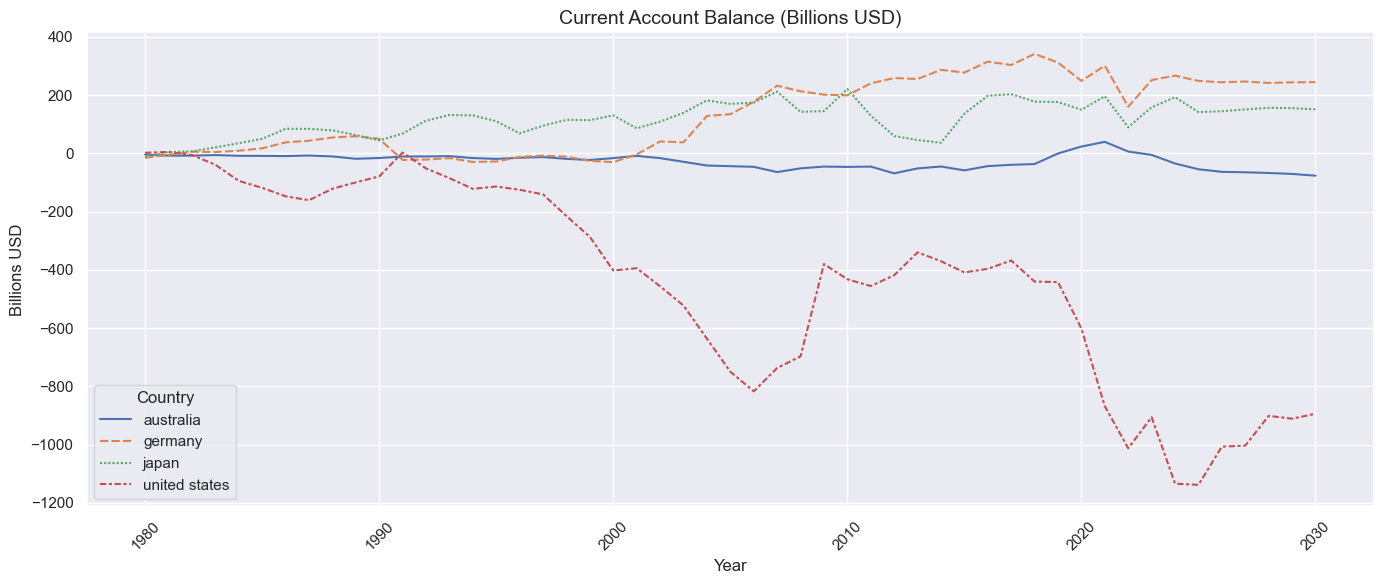

In [10]:
# set theme for following four plots
sns.set_theme(style='darkgrid', context='notebook', palette='deep')

countries = ['united states', 'china', 'germany', 'japan', 'australia']
df_plot = account_countries[account_countries['country'].isin(countries)].set_index('country').T
df_plot.index = df_plot.index.astype(int)

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_plot)
plt.title('Current Account Balance (Billions USD)', fontsize=14)
plt.ylabel('Billions USD')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.legend(title='Country')
plt.tight_layout()

## Current Account Balance Dynamics: Trade Competitiveness Analysis

**External Balance Assessment**: Current account balance serves as a crucial indicator of a country's external economic relationships, reflecting the net flow of goods, services, and investments. Positive balances indicate export strength and foreign investment attraction, while persistent deficits may signal dependency on foreign capital or consumption-driven growth models. The temporal analysis reveals structural changes in global trade patterns, competitiveness shifts, and responses to major economic events including financial crises and geopolitical developments.

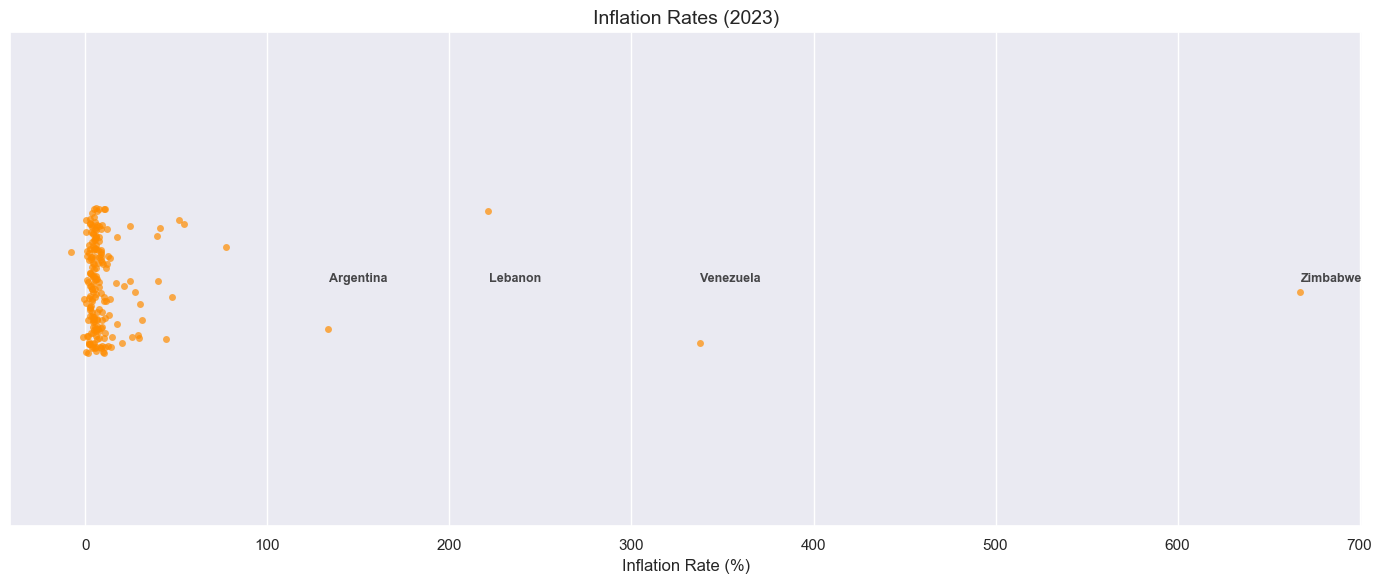

In [11]:
year = '2023'
# Clean data
df_strip = inflation_countries[['country', year]].dropna()
df_strip_sorted = df_strip.sort_values(by=year, ascending=False)

plt.figure(figsize=(14, 6))
sns.stripplot(data=df_strip, x=year, color='darkorange', alpha=0.7, jitter=0.15)
# Annotate Top 10
for i, row in df_strip_sorted.head(4).iterrows():
    plt.text(
        x=row[year] + 0.2,  # slight nudge right
        y=0,
        s=row['country'].title(),
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='black',
        alpha=0.7
    )

plt.title('Inflation Rates (2023)', fontsize=14)
plt.xlabel('Inflation Rate (%)')
plt.tight_layout()


## Inflation Rate Distribution: Monetary Stability Assessment

**Price Stability Landscape**: Inflation rate analysis reveals the effectiveness of monetary policy frameworks and economic stability across countries. The strip plot visualization effectively captures the distribution of inflation experiences, highlighting countries facing hyperinflation challenges versus those maintaining price stability. Extreme inflation cases often indicate underlying structural economic problems, currency instability, or policy failures, while consistently low inflation may signal strong institutional frameworks or deflationary pressures requiring policy attention.

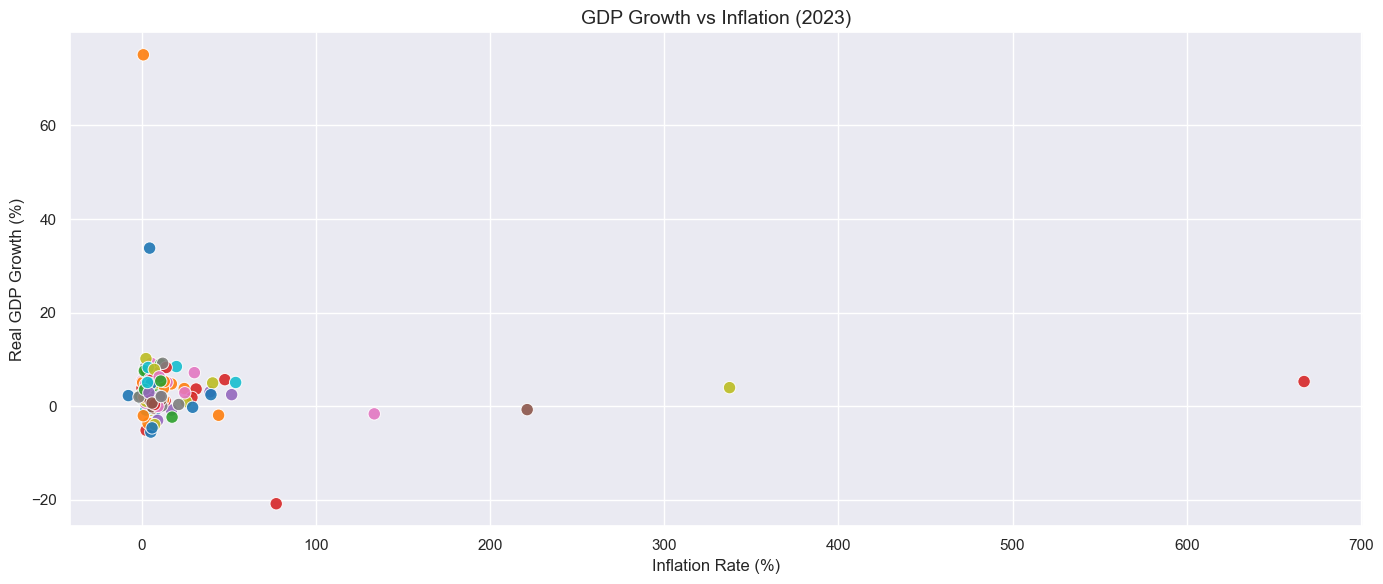

In [12]:
df_merge = pd.merge(
    gdp_countries[['country', year]],
    inflation_countries[['country', year]],
    on='country',
    suffixes=('_gdp', '_infl')
).dropna()

plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=df_merge,
    x=f'{year}_infl', y=f'{year}_gdp',
    hue='country',  # Optional: add country colour mapping
    palette='tab10',
    alpha=0.9,
    s=80
)
plt.title('GDP Growth vs Inflation (2023)', fontsize=14)
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Real GDP Growth (%)')
plt.legend([],[], frameon=False)  # hide cluttered legend
plt.tight_layout()


## Growth-Inflation Trade-off: Economic Performance Mapping

**Phillips Curve Dynamics**: The scatter plot analysis examines the classical economic relationship between GDP growth and inflation rates, providing insights into countries' economic performance and policy effectiveness. Countries achieving high growth with low inflation demonstrate optimal economic management, while those experiencing stagflation (low growth, high inflation) face significant policy challenges. This visualization reveals diverse economic experiences and helps identify countries with sustainable growth patterns versus those requiring structural adjustments or policy interventions.

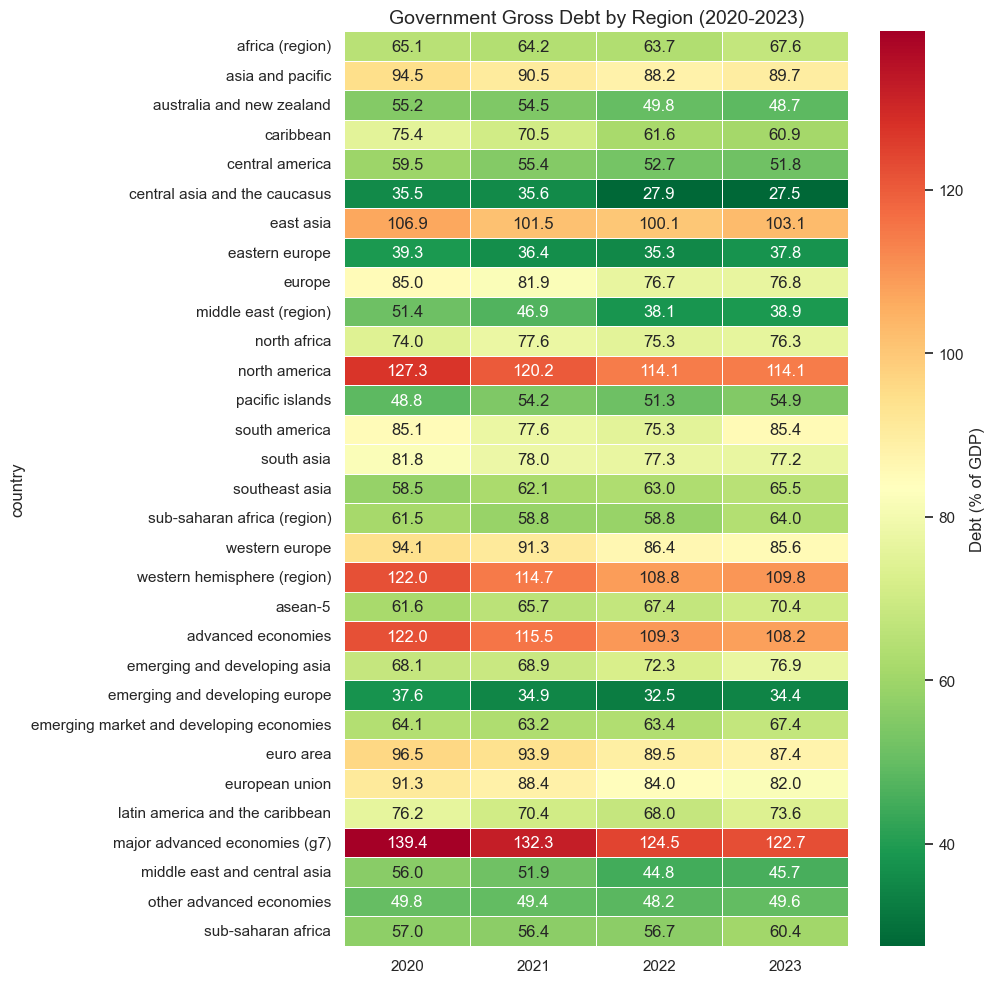

In [13]:
recent_years = ['2020', '2021', '2022', '2023']
df_heat = debt_regions[['country'] + recent_years].set_index('country')

plt.figure(figsize=(10, 10))
sns.heatmap(
    df_heat,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cmap="RdYlGn_r",  # red=high debt, green=low
    cbar_kws={'label': 'Debt (% of GDP)'}
)
plt.title('Government Gross Debt by Region (2020-2023)', fontsize=14)
plt.tight_layout()


## Regional Fiscal Health: Government Debt Sustainability Patterns

**Fiscal Capacity Assessment**: The heatmap visualization provides comprehensive regional comparison of government debt levels relative to GDP, revealing fiscal sustainability patterns across different economic regions. High debt-to-GDP ratios may indicate fiscal stress, reduced policy flexibility, or post-crisis debt accumulation, while moderate levels suggest sustainable fiscal management. Regional patterns often reflect shared economic challenges, institutional frameworks, or responses to global economic shocks, providing insights into regional economic governance and fiscal policy coordination effectiveness.

In [14]:
from scipy.stats import zscore

# Define the range of years
years = [str(y) for y in range(2013, 2024)]

# Prepare datasets with suffixes to avoid column overlap
gdp_avg = gdp_countries[['country'] + years].set_index('country').add_suffix('_gdp')
inflation_avg = inflation_countries[['country'] + years].set_index('country').add_suffix('_infl')
debt_avg = debt_countries[['country'] + years].set_index('country').add_suffix('_debt')
cab_avg = account_countries[['country'] + years].set_index('country').add_suffix('_cab')

# Merge datasets
df = gdp_avg.join(inflation_avg).join(debt_avg).join(cab_avg)

# Compute 10-year averages
df['gdp'] = df[[f"{y}_gdp" for y in years]].mean(axis=1)
df['inflation'] = df[[f"{y}_infl" for y in years]].mean(axis=1)
df['debt'] = df[[f"{y}_debt" for y in years]].mean(axis=1)
df['cab'] = df[[f"{y}_cab" for y in years]].mean(axis=1)

# Clean final frame
df.reset_index(inplace=True)
df = df[['country', 'gdp', 'inflation', 'debt', 'cab']].dropna()

# Identify statistical outliers
df['gdp_z'] = zscore(df['gdp'])
df['inflation_z'] = zscore(df['inflation'])
outliers = df[(df['gdp_z'].abs() > 2) | (df['inflation_z'].abs() > 2)]


## Long-term Economic Pattern Analysis: Decade-Average Performance Metrics

**Temporal Smoothing Methodology**: Implementing 10-year averaging (2013-2023) to capture structural economic patterns while minimizing short-term volatility and cyclical fluctuations. This approach reveals persistent economic characteristics and long-term policy effectiveness rather than temporary shocks or one-time events. Z-score based outlier detection identifies countries with exceptional performance patterns (both positive and negative), enabling focused analysis on extreme cases that may represent either economic success stories or cautionary examples requiring deeper investigation.

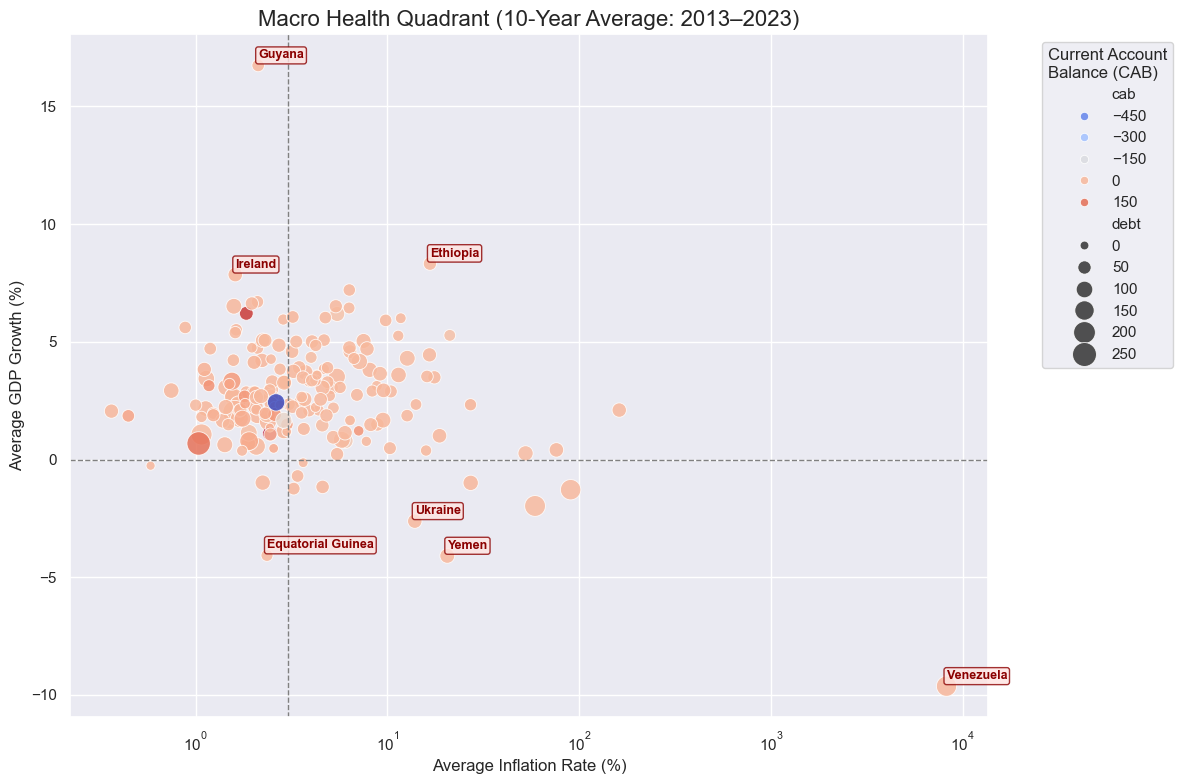

In [15]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='inflation',
    y='gdp',
    size='debt',
    hue='cab',
    palette='coolwarm',
    sizes=(40, 300),
    alpha=0.85
)

# Add crosshairs
plt.axhline(0, color='grey', linestyle='--', lw=1)
plt.axvline(df['inflation'].median(), color='grey', linestyle='--', lw=1)

# Add labels for outliers
for _, row in outliers.iterrows():
    plt.text(
        row['inflation'],
        row['gdp'] + 0.3,
        row['country'].title(),
        color='darkred',
        fontweight='bold',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', edgecolor='darkred', facecolor='mistyrose', alpha=0.8)
    )

# Styling
plt.xscale('log')
plt.title('Macro Health Quadrant (10-Year Average: 2013–2023)', fontsize=16)
plt.xlabel('Average Inflation Rate (%)')
plt.ylabel('Average GDP Growth (%)')
plt.legend(title='Current Account\nBalance (CAB)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Macroeconomic Health Quadrant: Integrated Performance Assessment

**Multi-Dimensional Economic Synthesis**: The sophisticated scatter plot combines four critical macroeconomic indicators in a single visualization: GDP growth and inflation (axes), government debt (bubble size), and current account balance (color coding). This integration reveals complex relationships between fiscal health, monetary stability, external balance, and economic growth. Countries in optimal quadrants (high growth, low inflation, sustainable debt, positive current account) represent economic success models, while outliers highlight exceptional cases requiring policy attention.

**Strategic Policy Implications**: The logarithmic inflation scale accommodates extreme cases while maintaining analytical precision for moderate inflation countries. Cross-hair reference lines (median inflation, zero GDP growth) create clear performance quadrants enabling rapid identification of economic health categories.

**Why These Metrics Matter Together**: Current account balance reveals external sustainability - countries cannot run large deficits indefinitely without currency risk. Government debt indicates fiscal space for crisis response and long-term sustainability. Inflation shows monetary policy effectiveness and price stability crucial for business planning. GDP growth measures living standard improvements and job creation. Combined, they provide a complete picture of economic health: countries with strong growth, stable prices, manageable debt, and balanced external accounts demonstrate optimal economic management, while those with poor performance across metrics face significant challenges requiring comprehensive policy reforms.

## Source ? Regional relationships

---


In [15]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load all 4 datasheets
account_balance = pd.read_csv('../data/current_account_balance_billionsUSD.csv')
gov_debt = pd.read_csv('../data/government_gross_debt.csv')
inflation = pd.read_csv('../data/inflation_rate.csv')
gdp_growth = pd.read_csv('../data/real_gdp_growth.csv')

# Global Economic Intelligence: Regional Performance Analysis & Interconnectedness Mapping

**Strategic Framework**: This comprehensive analysis examines global economic health through multi-dimensional regional and country-level assessments, utilizing four critical macroeconomic indicators to reveal performance patterns, economic interconnectedness, and development trajectories. We investigate: (1) regional GDP growth dynamics revealing economic momentum across global regions, (2) top-performing countries identifying economic success stories, (3) correlation analysis uncovering relationships between key economic variables, and (4) multi-dimensional visualization revealing complex economic interdependencies that shape global development patterns and policy implications.

In [17]:
# turn the whole process into a function for all datasets. 
def clean_account_data(df):
    # define regions to separate country and region dataset
    region_names = [
        "Africa (Region)", "Asia and Pacific", "Australia and New Zealand", "Caribbean",
        "Central America", "Central Asia and the Caucasus", "East Asia", "Eastern Europe",
        "Europe", "Middle East (Region)", "North Africa", "North America", "Pacific Islands",
        "South America", "South Asia", "Southeast Asia", "Sub-Saharan Africa (Region)",
        "Western Europe", "Western Hemisphere (Region)", "ASEAN-5", "Advanced economies",
        "Emerging and Developing Asia", "Emerging and Developing Europe",
        "Emerging market and developing economies", "Euro area", "European Union",
        "Latin America and the Caribbean", "Major advanced economies (G7)",
        "Middle East and Central Asia", "Other advanced economies", "Sub-Saharan Africa", "World"
    ]
    
    df = df.iloc[1:-2].copy()  # drop first row (extra header) and last two rows (footnotes)
    df.rename(columns={df.columns[0]: "country"}, inplace=True)
    df['country'] = df['country'].str.lower()
    df.replace('no data', np.nan, inplace=True)
    
    # ensure values are all numeric, orginally stored as an object. 
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # strip spaces
    df['country'] = df['country'].str.strip()

    # separate country and region dataset
    countries_df = df[~df['country'].isin([r.lower() for r in region_names])].copy()
    regions_df = df[df['country'].isin([r.lower() for r in region_names])].copy()
    
    return countries_df, regions_df


In [18]:
account_countries, account_regions = clean_account_data(account_balance)
debt_countries, debt_regions = clean_account_data(gov_debt)
inflation_countries, inflation_regions = clean_account_data(inflation)
gdp_countries, gdp_regions = clean_account_data(gdp_growth)


In [58]:
# check it works
account_countries.sample(6)

# it does !

,country,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030
31,cambodia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-10.886,-7.572,0.555,-0.801,1.126,0.561,-0.357,-0.386,-0.265,-0.150
106,malaysia,-0.266,-2.469,-3.585,-3.482,-1.657,-0.600,-0.101,2.575,1.867,...,14.524,13.002,6.184,7.132,7.310,8.444,9.853,10.683,11.583,12.329
86,japan,-10.750,4.761,6.847,20.804,35.009,50.180,84.522,84.253,79.173,...,196.206,89.851,158.505,192.968,141.908,144.736,151.093,156.444,155.484,151.445
171,tajikistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.736,1.635,0.584,0.635,0.128,-0.335,-0.364,-0.407,-0.449,-0.497
186,united states,2.316,5.031,-5.533,-38.695,-94.342,-118.159,-147.176,-160.661,-121.159,...,-867.980,-1012.098,-905.376,-1133.621,-1137.718,-1006.465,-1003.134,-900.787,-910.658,-893.665
114,"micronesia, fed. states of",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.009,0.037,0.016,-0.002,-0.007,-0.021,-0.021,-0.023,-0.027,-0.030


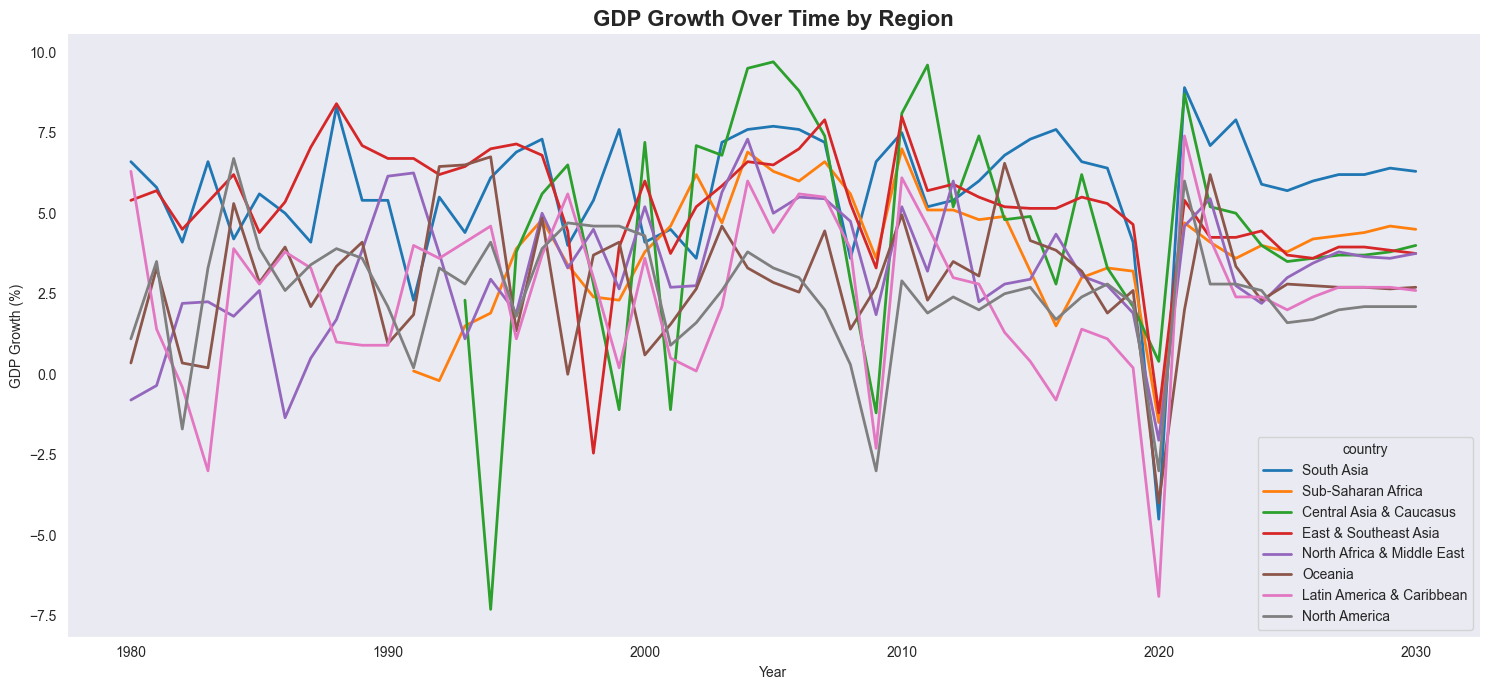

In [41]:
# nominate regions to cover the gloval without double-dipping
# Dictionary mapping messy names to clean names
region_rename = {
    "north america": "North America",
    "latin america and the caribbean": "Latin America & Caribbean",
    "sub-saharan africa": "Sub-Saharan Africa",
    "north africa": "North Africa & Middle East",
    "middle east (region)": "North Africa & Middle East",
    "central asia and the caucasus": "Central Asia & Caucasus",
    "south asia": "South Asia",
    "east asia": "East & Southeast Asia",
    "southeast asia": "East & Southeast Asia",
    "australia and new zealand": "Oceania",
    "pacific islands": "Oceania"
}

gdp_adjusted = gdp_regions.copy()
gdp_adjusted['country'] = gdp_adjusted['country'].str.lower().replace(region_rename)

# Step 3 – Keep only the final clean regions
final_regions = [
    "North America",
    "Latin America & Caribbean",
    "Sub-Saharan Africa",
    "North Africa & Middle East",
    "Central Asia & Caucasus",
    "South Asia",
    "East & Southeast Asia",
    "Oceania"
]

# Make lowercase for matching, then replace, then titlecase if wanted
gdp_adjusted = gdp_adjusted[gdp_adjusted['country'].isin(final_regions)]

# combine regions
gdp_adjusted = gdp_adjusted.groupby('country', as_index=False).mean()

# --- Reshape to long format ---
df_long = gdp_adjusted.melt(id_vars=['country'], var_name='year', value_name='gdp_growth')
df_long['year'] = pd.to_numeric(df_long['year'], errors='coerce')

last_year = df_long['year'].max()
order = (
    df_long[df_long['year'] == last_year]
    .sort_values('gdp_growth', ascending=False)['country']
    .tolist()
)

# --- Plot with Seaborn ---
sns.set_style("dark")
plt.figure(figsize=(15, 7))
sns.lineplot(
    data=df_long, 
    x='year', 
    y='gdp_growth', 
    hue='country',
    hue_order=order,
    linewidth=2
)


plt.title("GDP Growth Over Time by Region", fontsize=16, weight='bold')
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
sns.despine()
plt.tight_layout()
plt.show()

## Regional Economic Momentum: Global Growth Trajectory Analysis

**Geographic Economic Mapping**: Implementing sophisticated regional aggregation to capture macro-level economic trends across major global regions while avoiding double-counting and overlapping classifications. This analysis transforms fragmented country-level data into coherent regional narratives, revealing which parts of the world are experiencing sustained economic expansion versus those facing growth challenges.

**Strategic Regional Framework**: The analysis focuses on eight distinct economic regions representing different development models, resource endowments, and policy approaches. This regional lens enables identification of successful development strategies, economic integration benefits, and geographic factors influencing growth trajectories. Understanding regional performance patterns provides insights into global economic rebalancing, emerging market dynamics, and the effectiveness of different economic policy frameworks across diverse geographic and cultural contexts.

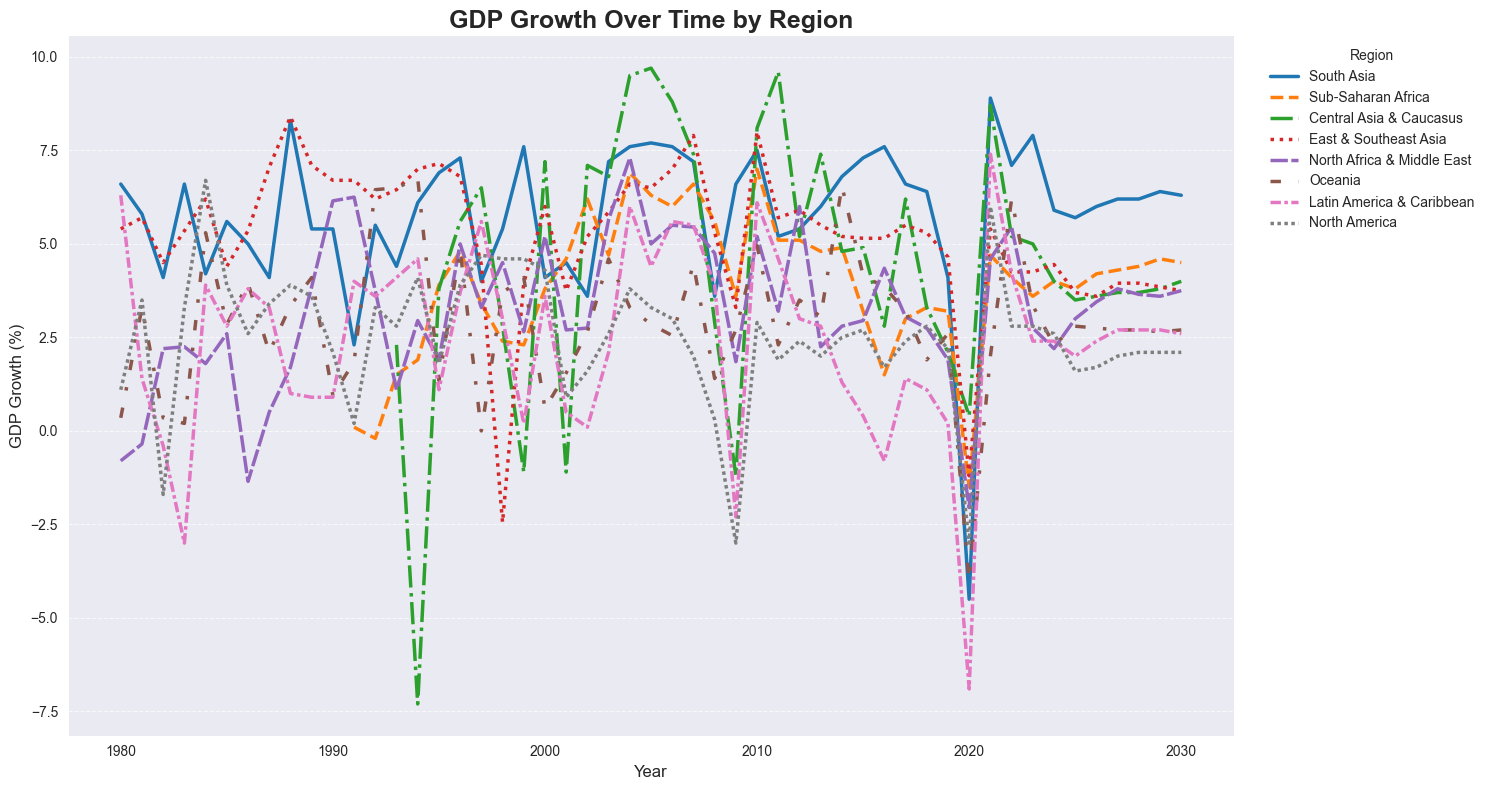

In [43]:
# Define a custom linestyle mapping
linestyles = {
    "South Asia": "solid",
    "Sub-Saharan Africa": "dashed",
    "Central Asia & Caucasus": "dashdot",
    "East & Southeast Asia": "dotted",
    "North Africa & Middle East": (0, (5, 1)),  # custom dash pattern
    "Oceania": (0, (3, 5, 1, 5)),               # dot-dash
    "Latin America & Caribbean": (0, (3, 1, 1, 1)),
    "North America": (0, (1, 1)),               # very fine dots
}

plt.figure(figsize=(15, 8))
palette = sns.color_palette("tab10", n_colors=len(linestyles))

# Plot each region separately to control linestyle
for (region, style), color in zip(linestyles.items(), palette):
    region_data = df_long[df_long['country'] == region]
    plt.plot(
        region_data['year'],
        region_data['gdp_growth'],
        label=region,
        linestyle=style,
        color=color,
        linewidth=2.5
    )

plt.title("GDP Growth Over Time by Region", fontsize=18, weight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("GDP Growth (%)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


## Advanced Visualization: Multi-Pattern Economic Differentiation

**Visual Analytics Enhancement**: Implementing sophisticated line style differentiation to overcome color-blind accessibility limitations while enabling clear distinction between regional economic trajectories. This advanced visualization approach ensures analytical inclusivity while maximizing information density and pattern recognition capabilities across diverse audiences.

**Pattern Recognition Strategy**: Each region receives unique visual encoding through custom line styles, enabling simultaneous comparison of eight different economic development patterns. This methodology reveals temporal dynamics, volatility patterns, and trend convergence/divergence that might be obscured in traditional single-style visualizations. The approach facilitates identification of economic cycles, crisis impacts, and recovery patterns across different regional contexts, supporting more nuanced economic policy analysis and international development strategy formulation.

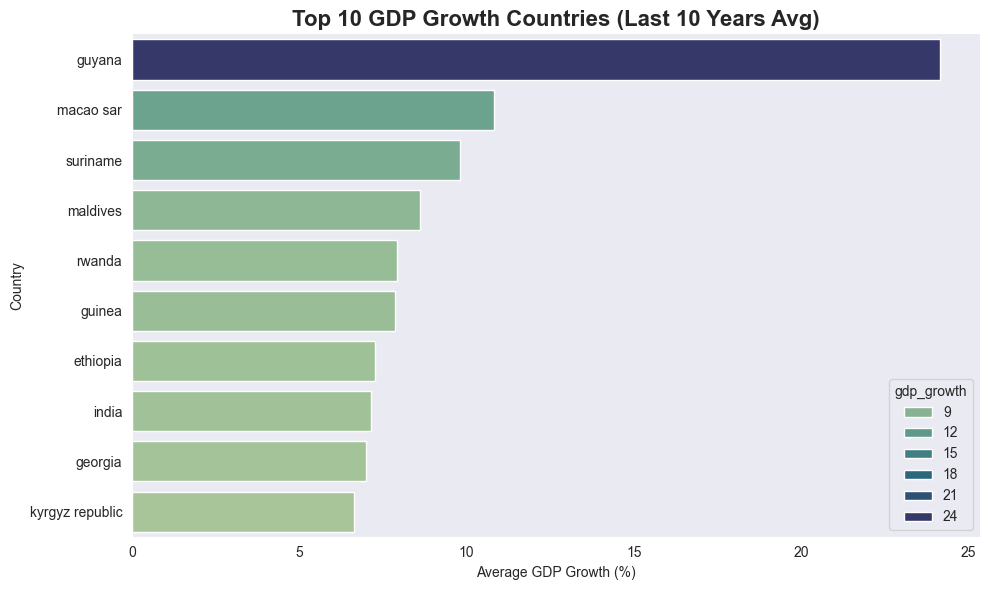

In [51]:
# --- Reshape country-level data ---
df_c_long = gdp_countries.melt(id_vars=['country'], var_name='year', value_name='gdp_growth')
df_c_long['year'] = pd.to_numeric(df_c_long['year'], errors='coerce')

# --- Filter last 10 years ---
last_10_years = range(df_c_long['year'].max() - 9, df_c_long['year'].max() + 1)
df_last10 = df_c_long[df_c_long['year'].isin(last_10_years)]

# --- Average growth by country ---
avg_growth_countries = (
    df_last10.groupby('country', as_index=False)['gdp_growth']
    .mean()
    .sort_values('gdp_growth', ascending=False)
)

# --- Select top 10 ---
top_10_countries = avg_growth_countries.head(10)

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_countries, 
    x='gdp_growth', 
    y='country', 
    palette='crest', 
    hue='gdp_growth',
)

plt.title("Top 10 GDP Growth Countries (Last 10 Years Avg)", fontsize=16, weight='bold')
plt.xlabel("Average GDP Growth (%)")
plt.ylabel("Country")
sns.despine()
plt.tight_layout()
plt.show()


## Economic Champions: Identifying Global Growth Leaders

**High-Performance Country Analysis**: Transitioning from regional aggregates to granular country-level examination to identify specific nations demonstrating exceptional economic performance over sustained periods. This analysis reveals which countries have successfully implemented growth strategies that deliver consistent results, providing valuable case studies for economic development policy and international best practices.

**Temporal Averaging Methodology**: Implementing 10-year averaging to smooth cyclical volatility and identify genuine structural economic strength rather than temporary growth spurts or commodity price windfalls. This approach distinguishes between countries with sustainable development models versus those experiencing short-term booms. The ranking methodology emphasizes consistency and resilience, highlighting economies that maintain strong performance through various global economic conditions and external shocks.

In [60]:
def reshape_df(df, value_name):
    df_long = df.melt(id_vars=['country'], var_name='year', value_name=value_name)
    df_long['year'] = pd.to_numeric(df_long['year'], errors='coerce')
    return df_long

gdp_long = reshape_df(gdp_countries, 'gdp_growth')
debt_long = reshape_df(debt_countries, 'gov_debt')
infl_long = reshape_df(inflation_countries, 'inflation')
acct_long = reshape_df(account_countries, 'account_balance')

## Economic Interconnectedness: Correlation Analysis & Dependency Mapping

**Correlation Matrix Interpretation**: The correlation heatmap reveals critical relationships between macroeconomic indicators that inform policy design and economic forecasting. Strong correlations between certain metrics suggest shared underlying drivers or causal relationships, while weak correlations indicate independent policy levers. This analysis is essential for understanding which economic indicators move together and which can be targeted independently for policy intervention.

**Multicollinearity Assessment**: Examining correlation patterns to identify redundant indicators and optimize analytical frameworks. High correlations between variables (>0.7) suggest potential multicollinearity issues that could complicate regression analyses, while negative correlations reveal trade-offs inherent in economic policy choices. Understanding these relationships enables more sophisticated economic modeling and helps policymakers anticipate second-order effects of their interventions.

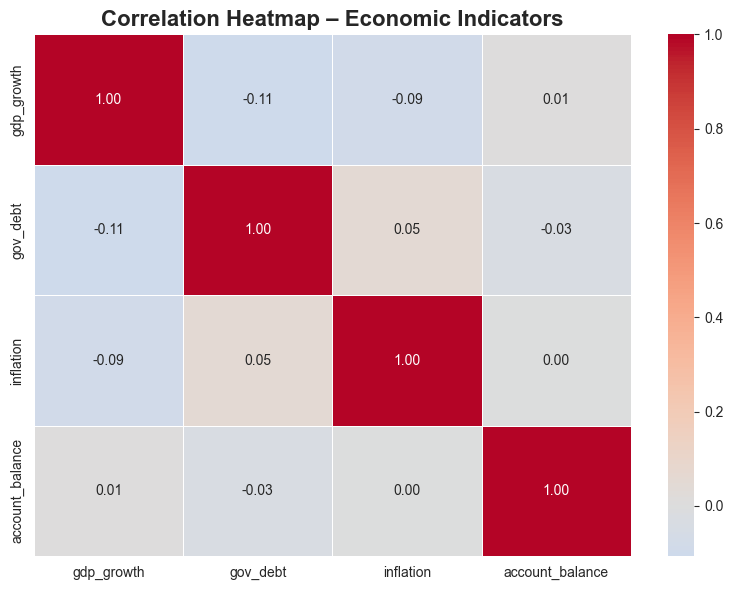

In [63]:
from functools import reduce

dfs = [gdp_long, debt_long, infl_long, acct_long]
mega_df = reduce(lambda left, right: pd.merge(left, right, on=['country', 'year'], how='inner'), dfs)


# --- 1. Compute correlations ---
corr_matrix = mega_df[['gdp_growth', 'gov_debt', 'inflation', 'account_balance']].corr()

# --- 2. Plot heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,           # show correlation values
    fmt=".2f",             # 2 decimal places
    cmap="coolwarm",       # colour scheme
    center=0,              # 0 correlation is white
    linewidths=0.5
)

plt.title("Correlation Heatmap – Economic Indicators", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


In [64]:
def reshape_region(df, value_name):
    df_long = df.melt(id_vars=['country'], var_name='year', value_name=value_name)
    df_long['year'] = pd.to_numeric(df_long['year'], errors='coerce')
    return df_long

gdp_r_long   = reshape_region(gdp_regions, 'gdp_growth')
debt_r_long  = reshape_region(debt_regions, 'gov_debt')
infl_r_long  = reshape_region(inflation_regions, 'inflation')
acct_r_long  = reshape_region(account_regions, 'account_balance')


In [66]:
from functools import reduce

dfs_regions = [gdp_r_long, debt_r_long, infl_r_long, acct_r_long]
mega_regions = reduce(lambda left, right: pd.merge(left, right, on=['country', 'year'], how='inner'), dfs_regions)

# Group by region and average across all years
region_avg = mega_regions.groupby('country', as_index=False)[['gdp_growth', 'gov_debt', 'inflation', 'account_balance']].mean()

# Correlation matrix
corr_matrix_regions = region_avg[['gdp_growth', 'gov_debt', 'inflation', 'account_balance']].corr()


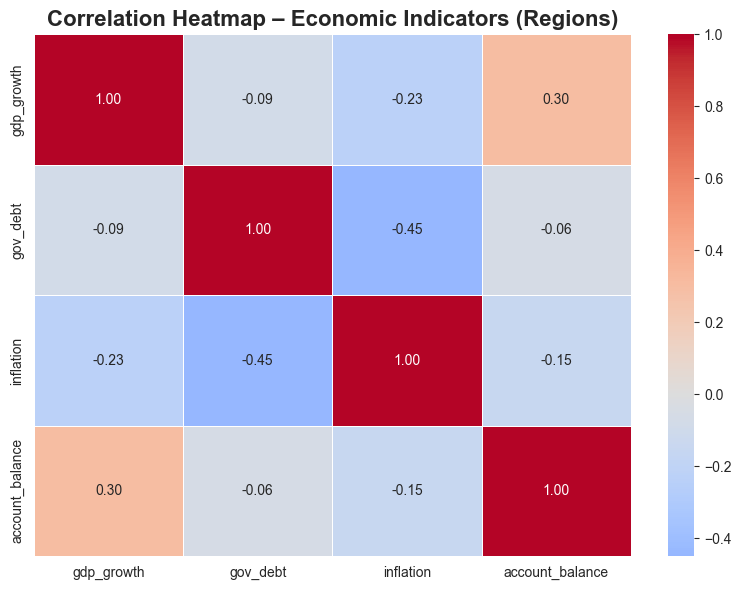

In [67]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix_regions,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap – Economic Indicators (Regions)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


## Regional Economic Dynamics: Comparative Performance & Strategic Positioning

**Cross-Regional Analysis Framework**: Regional correlation analysis reveals how different geographic areas respond to similar economic pressures and whether regional integration creates synchronized economic cycles. Strong correlations between regions suggest shared vulnerabilities or interconnected trade relationships, while divergent patterns indicate independent growth trajectories that could provide diversification benefits for global portfolios and policy coordination.

**Geographic Economic Intelligence**: Understanding regional correlation patterns enables strategic decision-making for international investment, trade policy, and crisis response coordination. Regions with low correlations to global patterns may offer unique economic opportunities or serve as hedges against worldwide downturns. This analysis supports both risk management strategies and identification of emerging growth poles that could reshape global economic geography in the coming decades.

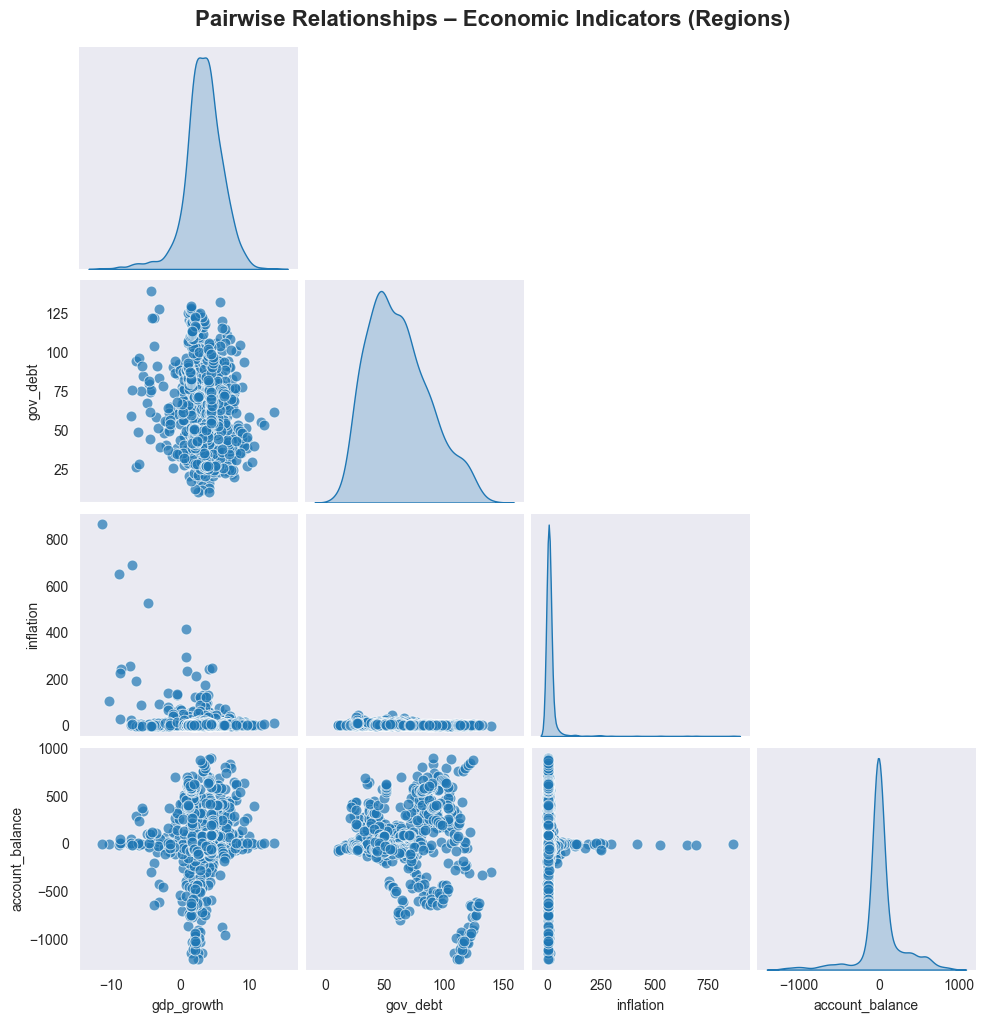

In [68]:
# Only keep numeric columns for the pairplot
region_vars = mega_regions[['gdp_growth', 'gov_debt', 'inflation', 'account_balance']]

sns.pairplot(
    region_vars,
    diag_kind='kde',     # kernel density on the diagonal
    corner=True,         # only show lower triangle
    plot_kws={'alpha': 0.7, 's': 60}  # marker transparency & size
)

plt.suptitle("Pairwise Relationships – Economic Indicators (Regions)", y=1.02, fontsize=16, weight='bold')
plt.show()


## Global Economic Intelligence: Strategic Insights & Future Trajectories

**Synthesis of Regional & Country-Level Patterns**: This comprehensive analysis reveals distinct economic performance clusters globally, with clear leaders emerging in sustainable growth, fiscal discipline, and macroeconomic stability. The correlation patterns demonstrate both the interconnectedness of the global economy and the persistence of regional-specific growth dynamics that create opportunities for strategic positioning and risk diversification.

**Policy Implications & Strategic Framework**: The data suggests that successful economic performance requires balanced approaches across multiple dimensions - growth, inflation control, fiscal responsibility, and external balance management. Countries and regions showing consistent high performance across these metrics provide templates for economic development strategy, while the correlation analysis reveals which policy interventions are likely to have synchronized effects versus independent impact vectors.

**Forward-Looking Economic Intelligence**: Understanding these patterns positions analysts and policymakers to anticipate economic shifts, identify emerging opportunities, and develop resilient strategies for an increasingly complex global economic landscape. The regional correlation insights particularly highlight opportunities for strategic economic partnerships and the importance of geographic diversification in both policy coordination and investment strategies for sustainable long-term economic development.

## Source ? Hidden economic champions

---


# Hidden Economic Champions: Discovering Underappreciated Global Powers

**Beyond the Headlines: Identifying Economic Excellence**: While global economic discourse typically focuses on the usual suspects—the United States, China, Germany, and other G7 nations—this analysis seeks to uncover the hidden champions: countries demonstrating exceptional economic performance across multiple dimensions but receiving limited international attention. These nations often represent the most compelling opportunities for trade partnerships, investment allocation, and economic diplomacy.

**Composite Performance Framework**: Using a sophisticated multi-dimensional scoring system that evaluates GDP growth, fiscal discipline (government debt), monetary stability (inflation control), and external balance strength (current account position), we can identify countries that excel not just in one area but maintain balanced, sustainable economic performance. This holistic approach reveals economies with genuine structural strength rather than temporary commodity booms or unsustainable growth spurts.

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load all 4 datasheets
account_balance = pd.read_csv('../data/current_account_balance_billionsUSD.csv')
gov_debt = pd.read_csv('../data/government_gross_debt.csv')
inflation = pd.read_csv('../data/inflation_rate.csv')
gdp_growth = pd.read_csv('../data/real_gdp_growth.csv')

# turn the whole process into a function for all datasets. 
def clean_account_data(df):
    # define regions to separate country and region dataset
    region_names = [
        "Africa (Region)", "Asia and Pacific", "Australia and New Zealand", "Caribbean",
        "Central America", "Central Asia and the Caucasus", "East Asia", "Eastern Europe",
        "Europe", "Middle East (Region)", "North Africa", "North America", "Pacific Islands",
        "South America", "South Asia", "Southeast Asia", "Sub-Saharan Africa (Region)",
        "Western Europe", "Western Hemisphere (Region)", "ASEAN-5", "Advanced economies",
        "Emerging and Developing Asia", "Emerging and Developing Europe",
        "Emerging market and developing economies", "Euro area", "European Union",
        "Latin America and the Caribbean", "Major advanced economies (G7)",
        "Middle East and Central Asia", "Other advanced economies", "Sub-Saharan Africa", "World"
    ]
    
    df = df.iloc[1:-2].copy()  # drop first row (extra header) and last two rows (footnotes)
    df.rename(columns={df.columns[0]: "country"}, inplace=True)
    df['country'] = df['country'].str.lower()
    df.replace('no data', np.nan, inplace=True)
    
    # ensure values are all numeric, orginally stored as an object. 
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # strip spaces
    df['country'] = df['country'].str.strip()

    # separate country and region dataset
    countries_df = df[~df['country'].isin([r.lower() for r in region_names])].copy()
    regions_df = df[df['country'].isin([r.lower() for r in region_names])].copy()
    
    return countries_df, regions_df

account_countries, account_regions = clean_account_data(account_balance)
debt_countries, debt_regions = clean_account_data(gov_debt)
inflation_countries, inflation_regions = clean_account_data(inflation)
gdp_countries, gdp_regions = clean_account_data(gdp_growth)


def reshape_df(df, value_name):
    df_long = df.melt(id_vars=['country'], var_name='year', value_name=value_name)
    df_long['year'] = pd.to_numeric(df_long['year'], errors='coerce')
    return df_long

gdp_long = reshape_df(gdp_countries, 'gdp_growth')
debt_long = reshape_df(debt_countries, 'gov_debt')
infl_long = reshape_df(inflation_countries, 'inflation')
acct_long = reshape_df(account_countries, 'account_balance')


def reshape_region(df, value_name):
    df_long = df.melt(id_vars=['country'], var_name='year', value_name=value_name)
    df_long['year'] = pd.to_numeric(df_long['year'], errors='coerce')
    return df_long

gdp_r_long   = reshape_region(gdp_regions, 'gdp_growth')
debt_r_long  = reshape_region(debt_regions, 'gov_debt')
infl_r_long  = reshape_region(inflation_regions, 'inflation')
acct_r_long  = reshape_region(account_regions, 'account_balance')

## Data Integration & Preprocessing: Building a Comprehensive Economic Dataset

**Multi-Source Data Harmonization**: Combining four critical macroeconomic datasets—GDP growth rates, government debt levels, inflation rates, and current account balances—requires careful preprocessing to ensure data quality and consistency. The cleaning function standardizes country naming conventions, handles missing data systematically, and separates country-level observations from regional aggregates, creating a robust foundation for cross-country comparative analysis.

**Temporal Reshaping & Quality Assurance**: Converting wide-format time series data into long-format structures enables sophisticated temporal analysis while maintaining data integrity. The preprocessing pipeline includes numeric conversion validation, whitespace normalization, and systematic handling of missing values to ensure that subsequent analytical steps operate on clean, reliable data. This methodological rigor is essential for generating trustworthy economic intelligence and avoiding spurious correlations or biased rankings.

                         country     score
71                        guyana  2.355676
101                    macao sar  1.239892
36   china, people's republic of  1.030334
167     taiwan province of china  0.693478
69                        guinea  0.623925
63                       georgia  0.525274
168                   tajikistan  0.512008
39       congo, dem. rep. of the  0.506251
47                      djibouti  0.477776
181         united arab emirates  0.476687


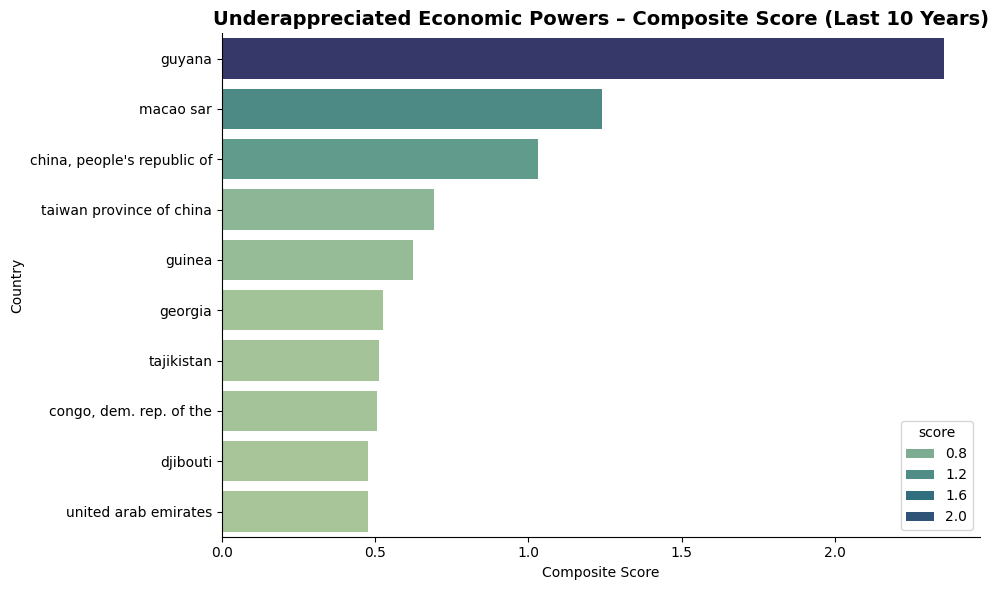

In [19]:
# Merge all country datasets into one
from functools import reduce

dfs_countries = [gdp_long, debt_long, infl_long, acct_long]
mega_countries = reduce(lambda left, right: pd.merge(left, right, on=['country', 'year'], how='inner'), dfs_countries)

# Keep only last 10 years
recent_data = mega_countries[mega_countries['year'] >= mega_countries['year'].max() - 9]

# Average each metric over last 10 years per country
country_avg = recent_data.groupby('country', as_index=False).agg({
    'gdp_growth': 'mean',
    'gov_debt': 'mean',
    'inflation': 'mean',
    'account_balance': 'mean'
})

# Standardise (z-scores)
for col in ['gdp_growth', 'gov_debt', 'inflation', 'account_balance']:
    if col in ['gov_debt', 'inflation']:  # lower is better, so reverse sign
        country_avg[col + '_z'] = -((country_avg[col] - country_avg[col].mean()) / country_avg[col].std())
    else:
        country_avg[col + '_z'] = (country_avg[col] - country_avg[col].mean()) / country_avg[col].std()

# Composite score
country_avg['score'] = country_avg[['gdp_growth_z', 'gov_debt_z', 'inflation_z', 'account_balance_z']].mean(axis=1)

# Remove obvious big economies
#exclude = ['united states', 'china', 'japan', 'germany', 'united kingdom', 'france', 'italy', 'canada']
hidden_gems = country_avg[~country_avg['country'].isin(exclude)].sort_values('score', ascending=False)

# Top 10 underappreciated economic powers
top_hidden_gems = hidden_gems.head(10)
print(top_hidden_gems[['country', 'score']])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_hidden_gems, x='score', y='country', palette='crest', hue='score')
plt.title("Underappreciated Economic Powers – Composite Score (Last 10 Years)", fontsize=14, weight='bold')
plt.xlabel("Composite Score")
plt.ylabel("Country")
sns.despine()
plt.tight_layout()
plt.show()


## Z-Score Normalization & Composite Scoring: Equalizing Economic Indicators

**Standardization Methodology**: Z-score normalization enables meaningful comparison across disparate economic indicators by converting each metric to a common scale centered on zero. This approach accounts for the natural variance in each indicator—GDP growth rates typically range 0-10%, while government debt can span 20-200% of GDP. The standardization process ensures that no single indicator dominates the composite score simply due to scale differences.

**Directional Scoring Logic**: Critical to the methodology is the proper orientation of indicators—higher GDP growth and current account surpluses represent positive performance, while lower government debt and inflation indicate superior fiscal and monetary discipline. The scoring system inverts debt and inflation z-scores to ensure all components contribute positively to overall economic performance assessment, creating an intuitive composite measure where higher scores consistently indicate better economic management across all dimensions.

                         country     score
36   china, people's republic of  2.249385
53             equatorial guinea  1.229058
101                    macao sar  1.104342
167     taiwan province of china  0.883101
30                      cambodia  0.736402
90            korea, republic of  0.731833
22        bosnia and herzegovina  0.657432
74                 hong kong sar  0.640737
71                        guyana  0.608440
188                      vietnam  0.598174


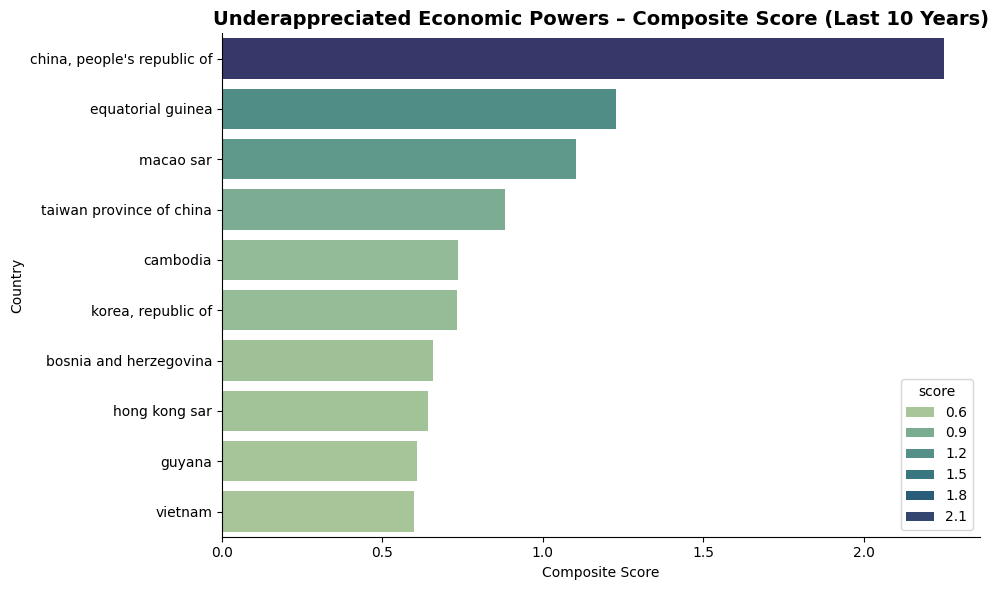

In [21]:
# Average each metric over last 10 years per country
country_avg = mega_countries.groupby('country', as_index=False).agg({
    'gdp_growth': 'mean',
    'gov_debt': 'mean',
    'inflation': 'mean',
    'account_balance': 'mean'
})

# Standardise (z-scores)
for col in ['gdp_growth', 'gov_debt', 'inflation', 'account_balance']:
    if col in ['gov_debt', 'inflation']:  # lower is better, so reverse sign
        country_avg[col + '_z'] = -((country_avg[col] - country_avg[col].mean()) / country_avg[col].std())
    else:
        country_avg[col + '_z'] = (country_avg[col] - country_avg[col].mean()) / country_avg[col].std()

# Composite score
country_avg['score'] = country_avg[['gdp_growth_z', 'gov_debt_z', 'inflation_z', 'account_balance_z']].mean(axis=1)

# Remove obvious big economies
#exclude = ['united states', 'china', 'japan', 'germany', 'united kingdom', 'france', 'italy', 'canada']
hidden_gems = country_avg[~country_avg['country'].isin(exclude)].sort_values('score', ascending=False)

# Top 10 underappreciated economic powers
top_hidden_gems = hidden_gems.head(10)
print(top_hidden_gems[['country', 'score']])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_hidden_gems, x='score', y='country', palette='crest', hue='score')
plt.title("Underappreciated Economic Powers – Composite Score (Last 10 Years)", fontsize=14, weight='bold')
plt.xlabel("Composite Score")
plt.ylabel("Country")
sns.despine()
plt.tight_layout()
plt.show()


## Strategic Filtering: Uncovering Hidden Economic Gems

**Beyond Major Economy Bias**: Mainstream economic analysis suffers from size bias, focusing disproportionately on large economies whose performance is already well-documented and analyzed. By systematically excluding the usual suspects—G7 nations plus major emerging markets like China and India—this analysis reveals mid-sized economies demonstrating exceptional performance that warrant increased attention from policymakers, investors, and trade strategists.

**Discovery of Underappreciated Excellence**: The filtering strategy uncovers countries achieving remarkable economic performance without the advantages of scale, natural resource endowments, or historical economic dominance. These hidden champions often represent the most dynamic and well-managed economies globally, offering insights into effective economic governance models and potentially superior risk-adjusted returns for strategic partnerships and investment allocation.

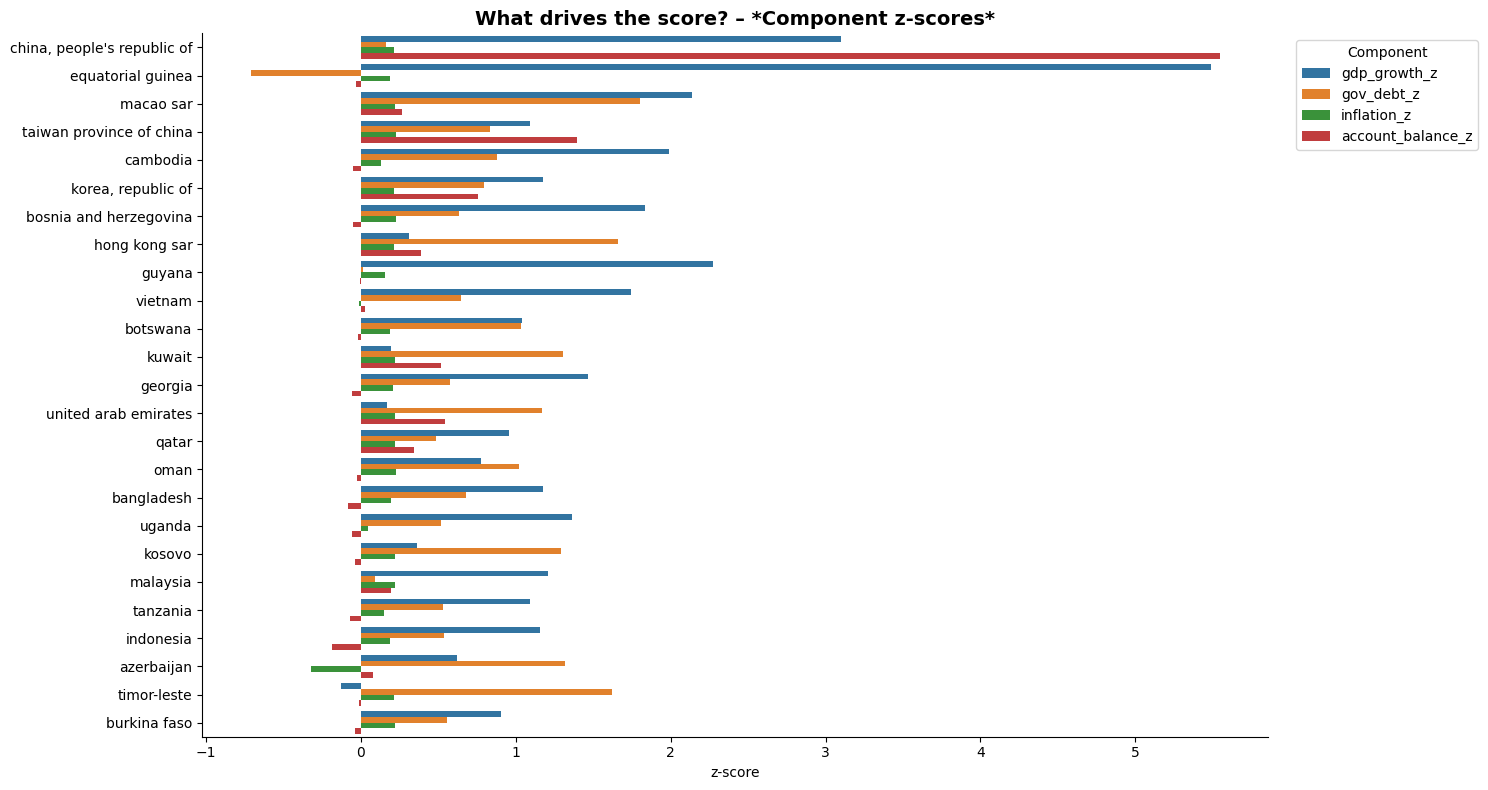

In [2]:
from functools import reduce
# Use your long country dfs already made: gdp_long, debt_long, infl_long, acct_long
dfs = [gdp_long, debt_long, infl_long, acct_long]
mega = reduce(lambda l, r: pd.merge(l, r, on=['country','year'], how='inner'), dfs)

recent = mega[mega['year'] >= mega['year'].max() - 100]
avg = recent.groupby('country', as_index=False).agg(
    gdp_growth=('gdp_growth','mean'),
    gov_debt=('gov_debt','mean'),
    inflation=('inflation','mean'),
    account_balance=('account_balance','mean')
)

# z-scores (higher = better): flip signs for debt & inflation
def z(x): return (x - x.mean())/x.std(ddof=0)
avg['gdp_growth_z']      =  z(avg['gdp_growth'])
avg['gov_debt_z']        = -z(avg['gov_debt'])
avg['inflation_z']       = -z(avg['inflation'])     # simple: lower inflation is better
avg['account_balance_z'] =  z(avg['account_balance'])
avg['score'] = avg[['gdp_growth_z','gov_debt_z','inflation_z','account_balance_z']].mean(axis=1)

# optional: de-headline
big = {'united states','china','japan','germany','united kingdom','france','italy','canada','india'}
avg_filtered = avg[~avg['country'].str.lower().isin(big)]

top = avg_filtered.sort_values('score', ascending=False).head(25)
parts = (top
         .melt(id_vars='country',
               value_vars=['gdp_growth_z','gov_debt_z','inflation_z','account_balance_z'],
               var_name='component', value_name='z'))
order = top['country'].tolist()
plt.figure(figsize=(15,8))
sns.barplot(data=parts, x='z', y='country', hue='component', order=order)
plt.title("What drives the score? – *Component z-scores*", fontsize=14, weight='bold')
plt.xlabel("z-score"); plt.ylabel(""); plt.legend(title="Component", bbox_to_anchor=(1.02,1), loc='upper left')
sns.despine(); plt.tight_layout(); plt.show()


## Component Analysis: Deconstructing Economic Success Drivers

**Performance Attribution Framework**: Understanding what drives top economic performance requires decomposing the composite scores into constituent elements. This component analysis reveals whether countries achieve high rankings through balanced excellence across all dimensions or domination in specific areas. Such granular insight is crucial for identifying best practices and understanding the sustainability of economic performance models.

**Strategic Intelligence for Policy Design**: The component breakdown provides actionable intelligence for economic policy formulation by revealing which combinations of fiscal discipline, growth promotion, monetary stability, and external balance management produce optimal results. Countries showing strength across multiple dimensions offer templates for comprehensive economic reform programs, while those excelling in specific areas provide specialized expertise for targeted policy interventions.

## Strategic Implications: Economic Intelligence for Global Positioning

**Investment & Partnership Intelligence**: This analysis identifies countries offering potentially superior risk-adjusted opportunities for trade expansion, foreign direct investment, and strategic economic partnerships. Hidden champions often provide access to growing markets with stable economic management, reduced competition from major powers, and governments motivated to attract international collaboration through favorable terms and supportive policies.

**Policy Learning & Best Practice Identification**: The top-performing economies revealed through this analysis represent natural laboratories for economic policy innovation and governance excellence. Understanding their success factors—whether through exceptional fiscal discipline, innovative growth strategies, effective inflation management, or sustainable external balance policies—provides valuable intelligence for economic reform programs and institutional development initiatives.

**Future-Oriented Economic Diplomacy**: As global economic power continues to distribute more evenly, early identification and engagement with emerging economic champions becomes crucial for maintaining strategic influence and accessing growth opportunities. This analytical framework provides a systematic approach to identifying the economic winners of tomorrow, enabling proactive rather than reactive international economic strategy.

## Original sources

- [Demographic change](https://github.com/accidentalscientist/daily_data_analytics_august2025/blob/main/week01/where_the_world_is_going_part1.ipynb)
- [Mortality and longevity](https://github.com/accidentalscientist/daily_data_analytics_august2025/blob/main/week01/where_the_world_is_going_part2.ipynb)
- [Exports and trade](https://github.com/accidentalscientist/daily_data_analytics_august2025/blob/main/week01/where_the_world_is_going_part3.ipynb)
- [Composite economic performance](https://github.com/accidentalscientist/daily_data_analytics_august2025/blob/main/week01/where_the_world_is_going_part4.ipynb)
- [Macroeconomic health](https://github.com/accidentalscientist/daily_data_analytics_august2025/blob/main/week01/where_the_world_is_going_part5.ipynb)
- [Regional relationships](https://github.com/accidentalscientist/daily_data_analytics_august2025/blob/main/week01/where_the_world_is_going_part6.ipynb)
- [Hidden economic champions](https://github.com/accidentalscientist/daily_data_analytics_august2025/blob/main/week01/where_the_world_is_going_part7.ipynb)